# Goal:
1. Is the riemannian Hessian hermitian? (real eigenvalues)
2. Can we still apply the gaussian quadrature method to it regardless.
3. What steps need to be changed to be applicable.

# Steps:
1. Verify if hermitian and eigenvalues conditions ✅
2. Evaluate current algorithm on Hermitian matrix to become familiar with the individual steps
    * Copy code from Github repo and bring up to date with current jax implementation
3. Try it out with minimal modifications for Riemannian Hessian and verify eigenspectrum
    * Change to complex case
    * Sample from the right distribution
4. If fails, try with the hermitian version of rH, i.e. (rH + rH^\dagger)/2
    * Is the result somewhat close enough?
5. If fails, make major modifications:
    * Change the way we compute the weights and nodes to work with non-hermitian matrices.
6. Understand if the real spectrum is an accident or something I can exploit.

# Question to ask ChatGPT:

1.  Given a metric for the tangent space of a manifold. How do I sample vectors uniformly distributed in this space? For instance, for the tangent space of the Stiefel Manifold.
2. How can I calculate the Gaussian quadrature weights and nodes in the case where my matrix is a complex non-hermitian matrix.


# Notes from discussion with Raphael:
1. What makes a matrix have real values? Our matrix is not hermitian or normal, so what kind of structure is it?
2. The eigenvalue distribution of the $\mathrm{Herm}(H)$ is different than the eigenvalue distribution of $H$.
3. IDEA 💡: (Hypothesis) we don't really care about the exact number of degrees of freedom from our cost function, but rather that it has converged with respect to the number of sequences. If the conversion from Euclidean -> Stiefel fixes a `constant` number of parameters (constant independent on the number of sequences), then we only care about evaluating the spectrum of the euclidean Hessian and see the convergence with number of sequences ⁉️
    * Test this hypothesis: compute the Riemannian and Euclidean Hessian spectral density (around zero) for different number of sequences to verify our hypothesis
    * If this turns out to be true, back it up with an analytical relation.
    * Then we can simply use the relation for the euclidean Hessian with the Lanczos algorithm and Gaussian Quadrature on complex matrices - since the Euclidean Hessian is hermitian.

# Imports

In [1]:
%load_ext autoreload
%autoreload 2
# External imports
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
# Internal imports
from mGST.algorithm import riemannian_hessian_povm
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_rep_from_mgst_output, compute_euclidean_hessian_kraus

from mGST.utility_functions_comparisons import compute_euclidean_derivatives_kraus
from mGST.additional_fns import transp

backend = "iqmfakeapollo"

# Setup

In [2]:
num_qubits = 2
dim = 2**num_qubits
kraus_rank = dim**2
state_rank = dim
povm_rank = dim

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-01-21 12:59:31,786 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2026-01-21 12:59:32,214 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2026-01-21 12:59:32,214 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-01-21 12:59:33,855 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2026-01-21 12:59:33,864 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-01-21 12:59:33,920 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2026-01-21 12:59:37,995:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-01-21 12:59:37,995 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [6]:
kraus_tensor_jax, povm_psd_jax, state_psd_jax = get_compressed_rep_from_mgst_output(kraus_mgst, povm_mgst, state_mgst, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

povm_psd_mgst = np.array(povm_psd_jax)
state_psd_mgst = np.array(state_psd_jax)

# Hessian (POVM)

In [10]:
num_povm, rank_povm, dim = povm_psd_mgst.shape # num_povm, rank_povm, dim
n = num_povm * rank_povm
p = dim

rhessian_tensor = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    return_gradient=False,
    hermitian_order=False,
)

rhessian_matrix = rhessian_tensor.reshape(2 * n * p, 2 * n * p)

# is this the hermitian matrix we expect?
rhessian_matrix_adjoint = rhessian_matrix.conj().T
jnp.allclose(rhessian_matrix, rhessian_matrix_adjoint)

Array(False, dtype=bool)

In [11]:
rhessian_tensor_herm_order = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    return_gradient=False,
    hermitian_order=True,
)

rhessian_matrix_herm_order = rhessian_tensor_herm_order.reshape(2 * n * p, 2 * n * p)

# is this the hermitian matrix we expect?
rhessian_matrix_adjoint_herm_order = rhessian_matrix_herm_order.conj().T
jnp.allclose(rhessian_matrix_herm_order, rhessian_matrix_adjoint_herm_order)

Array(False, dtype=bool)

Neither is expected to be hermitian, since they are both hermitian computed with the canonical metric

## Evaluate spectrum

### Basic tests

In [26]:
# Is it hermitian?
rhessian_matrix_adjoint = rhessian_matrix.conj().T
print(jnp.allclose(rhessian_matrix, rhessian_matrix_adjoint), jnp.linalg.norm(rhessian_matrix - rhessian_matrix_adjoint))

eigvals = jnp.linalg.eigvals(rhessian_matrix)
eigvals_adjoint = jnp.linalg.eigvals(rhessian_matrix_adjoint)

eigvals_real = eigvals.real
eigvals_imag = eigvals.imag
eigvals_adjoint_real = eigvals_adjoint.real
eigvals_adjoint_imag = eigvals_adjoint.imag

print('Are they the same eigvals: ', jnp.allclose(eigvals, eigvals_adjoint))
print('Are the real parts the same: ', jnp.allclose(eigvals_real, eigvals_adjoint_real))
print('Are the imag parts the same: ', jnp.allclose(eigvals_imag, eigvals_adjoint_imag))

eigvals_real = jnp.sort(eigvals_real, descending=True)
eigvals_adjoint_real = jnp.sort(eigvals_adjoint_real, descending=True)
print('What about if we order the real ones: ', jnp.allclose(eigvals_real, eigvals_adjoint_real))

False 0.047044618008178066
Are they the same eigvals:  False
Are the real parts the same:  False
Are the imag parts the same:  True
What about if we order the real ones:  True


In [27]:
rhessian_matrix_hermitian = 0.5 * (rhessian_matrix + rhessian_matrix.conj().T)
eigvals_hermitian = jnp.linalg.eigvals(rhessian_matrix_hermitian)
eigvals_real = jnp.sort(eigvals_real, descending=True)
eigvals_hermitian_real = jnp.sort(eigvals_hermitian.real, descending=True)
print('Comparing hermitian real eigvals with original real eigvals: ', jnp.allclose(eigvals_real, eigvals_hermitian_real))

Comparing hermitian real eigvals with original real eigvals:  False


2025-12-11 16:34:03,380 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:03,384 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:03,418 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:03,422 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


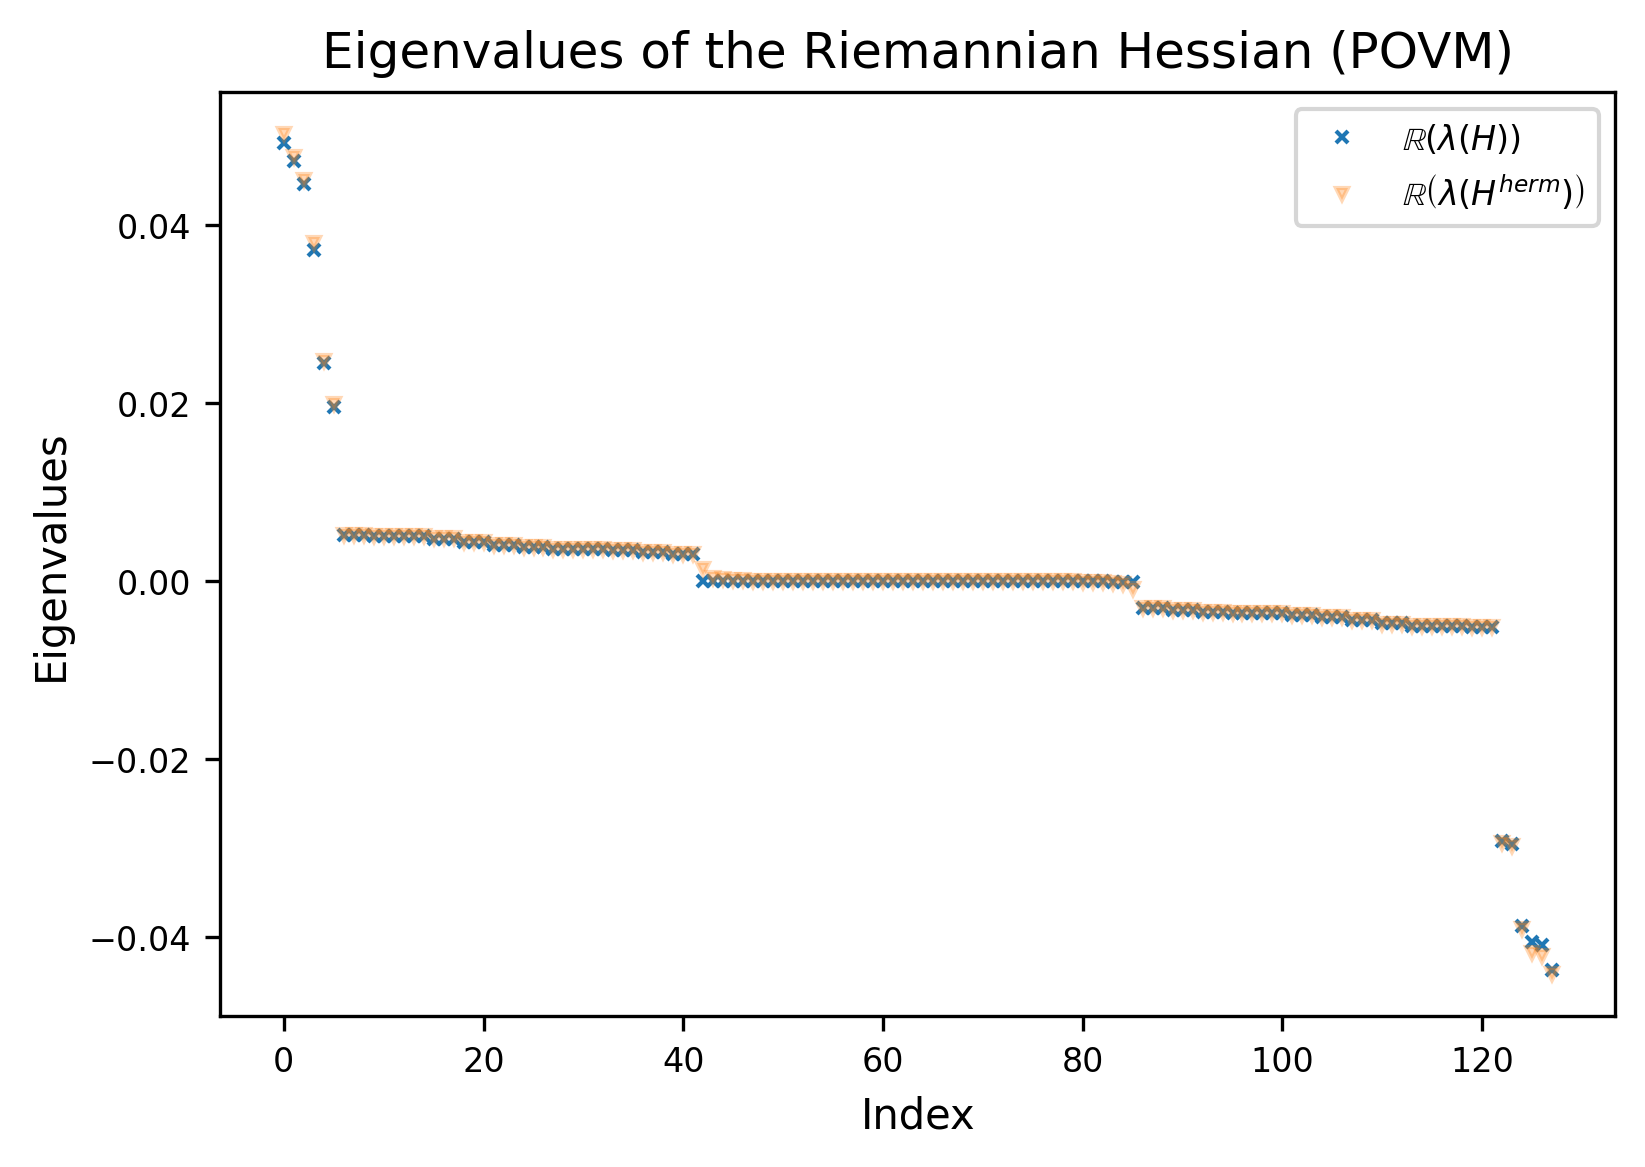

In [28]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Eigenvalues of the Riemannian Hessian (POVM)", fontsize=12)
plt.plot(eigvals_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H) \right)$")
plt.plot(eigvals_hermitian_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H^{herm}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

2025-12-11 16:34:27,378 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,382 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-12-11 16:34:27,383 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-12-11 16:34:27,387 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,391 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-12-11 16:34:27,391 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-12-11 16:34:27,429 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,432 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-12-11 16:34:27,432 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-12-11 16:34:27,435 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,439 - matplotlib.matht

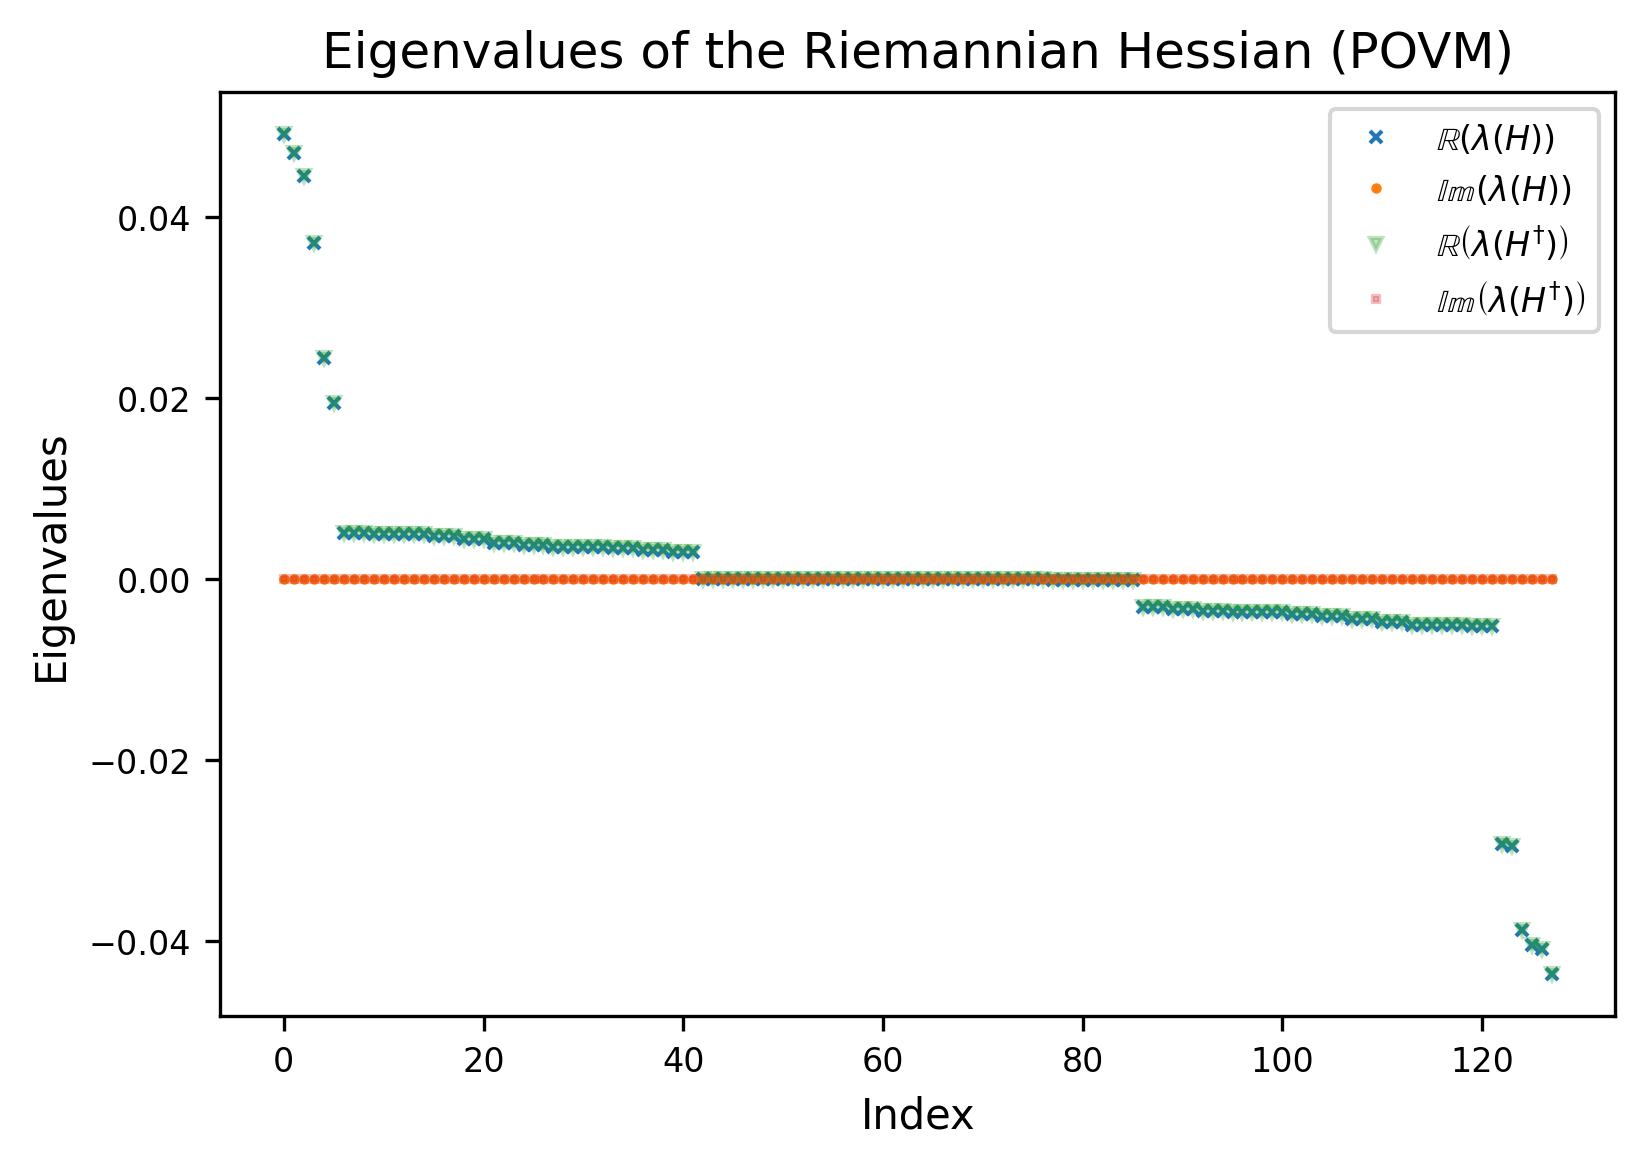

In [29]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Eigenvalues of the Riemannian Hessian (POVM)", fontsize=12)
plt.plot(eigvals_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H) \right)$")
plt.plot(eigvals_imag, "o", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H) \right)$")
plt.plot(eigvals_adjoint_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.plot(eigvals_adjoint_imag, "s", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

2025-11-20 17:05:00,267 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,272 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-11-20 17:05:00,272 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-11-20 17:05:00,276 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,279 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-11-20 17:05:00,280 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-11-20 17:05:00,317 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,320 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-11-20 17:05:00,321 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-11-20 17:05:00,324 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,327 - matplotlib.matht

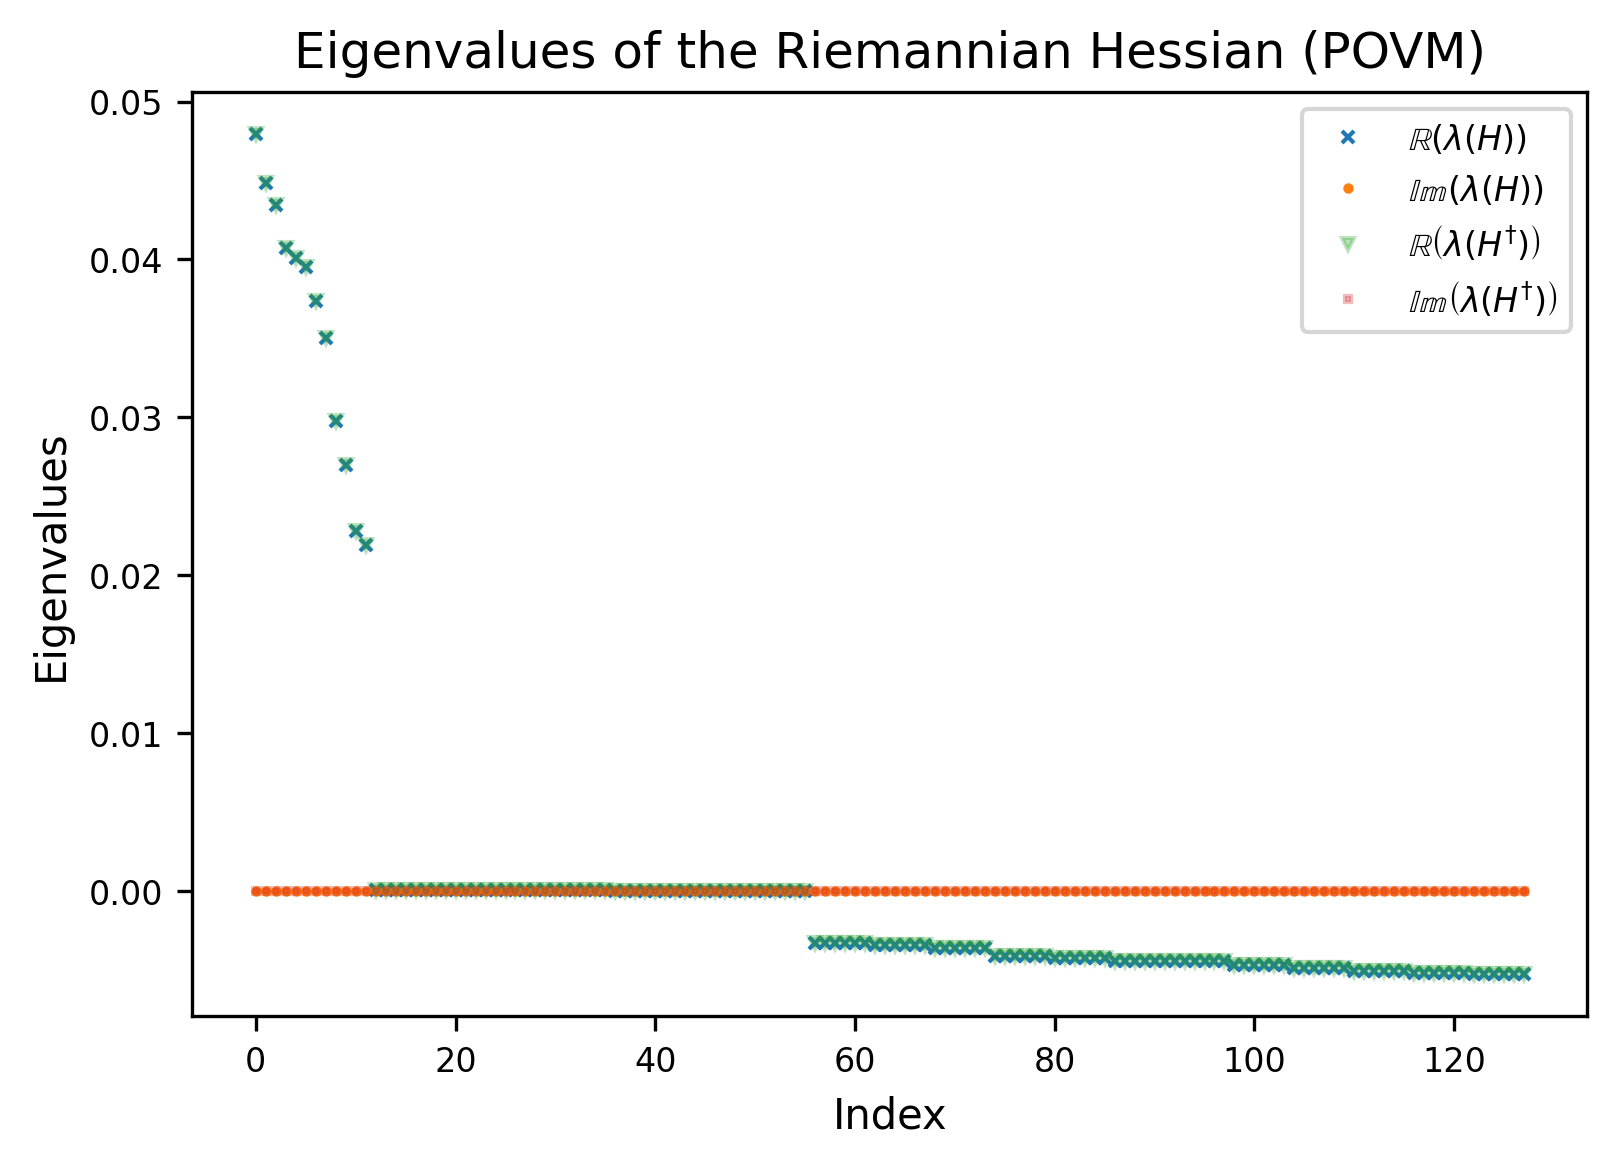

In [65]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Eigenvalues of the Riemannian Hessian (POVM)", fontsize=12)
plt.plot(eigvals_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H) \right)$")
plt.plot(eigvals_imag, "o", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H) \right)$")
plt.plot(eigvals_adjoint_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.plot(eigvals_adjoint_imag, "s", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

### Further tests

In [106]:
# So the eigenvalues are the same but how would the eigenvectors look like?
eigenvals, eigenvects = jnp.linalg.eig(rhessian_matrix)
# test orthogonality of eigenvectors
eigenvects[:,4].conj().T @ eigenvects[:, 100]

Array(-3.72970452e-18+3.93918607e-17j, dtype=complex128)

In [ ]:
print(jnp.linalg.cond(rhessian_matrix))

jnp.linalg.norm(eigenvects @ eigenvects.conj().T - jnp.eye(eigenvects.shape[0]))

1.9298057418795313e+18


Array(8.11395526, dtype=float64)

In [94]:
(eigenvects @ eigenvects.conj().T)[1, 0]

Array(0.09606166-0.04362011j, dtype=complex128)

In [ ]:
rhessian_kraus_mgst = rhessian_matrix
Hh = rhessian_kraus_mgst.conj().T

# absolute and relative Hermiticity error
norm_diff = jnp.linalg.norm(rhessian_kraus_mgst - Hh)
norm_H = jnp.linalg.norm(rhessian_kraus_mgst)
print("||H - H^†||_F =", norm_diff)
print("relative ||H - H^†|| / ||H|| =", norm_diff / norm_H)

# check normality (A A^† == A^† A ?)
comm = rhessian_kraus_mgst @ Hh - Hh @ rhessian_kraus_mgst
print("||[H, H^†]||_F (zero => normal):", jnp.linalg.norm(comm))
print("is normal (allclose)?", jnp.allclose(rhessian_kraus_mgst @ Hh, Hh @ rhessian_kraus_mgst))

# Hermitian and anti-Hermitian parts
H_sym = 0.5 * (rhessian_kraus_mgst + Hh)   # Hermitian part
H_asym = 0.5 * (rhessian_kraus_mgst - Hh)  # anti-Hermitian part
print("||Hermitian part||, ||anti-Hermitian part||:",
      jnp.linalg.norm(H_sym), jnp.linalg.norm(H_asym))

# optionally inspect eigenvectors (right eigenvectors)
eigvals, eigvecs = jnp.linalg.eig(rhessian_kraus_mgst)
eigvals_h, eigvecs_h = jnp.linalg.eig(Hh)
# You can compare eigenvectors corresponding to matched eigenvalues after sorting/matching.


||H - H^†||_F = 0.03263829087273501
relative ||H - H^†|| / ||H|| = 0.2418294956480749
||[H, H^†]||_F (zero => normal): 0.0014312822077706272
is normal (allclose)? False
||Hermitian part||, ||anti-Hermitian part||: 0.13397381584667079 0.016319145436367505


In [ ]:
H_herm = 0.5 * (rhessian_kraus_mgst + rhessian_kraus_mgst.conj().T)
eigvals_hermitian = jnp.linalg.eigvals(H_herm)
jnp.linalg.norm(jnp.sort(eigvals_hermitian.real) - jnp.sort(eigvals.real)) / jnp.linalg.norm(eigenvals.real)

Array(0.01589143, dtype=float64)

## Euclidean vs Riemannian Hessian convergence against `num_sequences`

Metric for convergence? Condition number?

In [ ]:
# Step 1: Compute the Euclidean Hessian and its spectrum
ehessian_tensor = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    euclidean=True,
    return_gradient=False,
    hermitian_order=True,
)
ehessian_matrix = ehessian_tensor.reshape(2 * dim * p, 2 * dim * p)

# is this the hermitian matrix we expect?
ehessian_matrix_adjoint = ehessian_matrix.conj().T
print(jnp.allclose(ehessian_matrix, ehessian_matrix_adjoint))

True


In [ ]:
ehessian_tensor_nonherm = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    euclidean=True,
    return_gradient=False,
    hermitian_order=False
)
ehessian_matrix_nonherm = ehessian_tensor_nonherm.reshape(2 * dim * p, 2 * dim * p)

# is this the hermitian matrix we expect?
ehessian_matrix_adjoint_nonherm = ehessian_matrix_nonherm.conj().T
print(jnp.allclose(ehessian_matrix_nonherm, ehessian_matrix_adjoint_nonherm))

False


## Spectrum calculation

In [35]:
eeigvals = jnp.linalg.eigvals(ehessian_matrix)
eeigvals_real = eeigvals.real
eeigvals_real_ordered = jnp.sort(eeigvals_real, descending=True)

eeigvals_imag = eeigvals.imag
jnp.linalg.norm(eeigvals_imag), jnp.linalg.norm(eeigvals_real)

(Array(9.80613256e-18, dtype=float64), Array(0.24753905, dtype=float64))

In [45]:
eeigvals_nonherm = jnp.linalg.eigvals(ehessian_matrix_nonherm)
eeigvals_real_nonherm = eeigvals_nonherm.real
eeigvals_real_ordered_nonherm = jnp.sort(eeigvals_real_nonherm, descending=True)

eeigvals_imag_nonherm = eeigvals_nonherm.imag
jnp.linalg.norm(eeigvals_imag_nonherm), jnp.linalg.norm(eeigvals_real_nonherm)

(Array(1.69899223e-17, dtype=float64), Array(0.24535512, dtype=float64))

2025-12-12 14:33:56,688 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,694 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,699 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,758 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,765 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,769 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


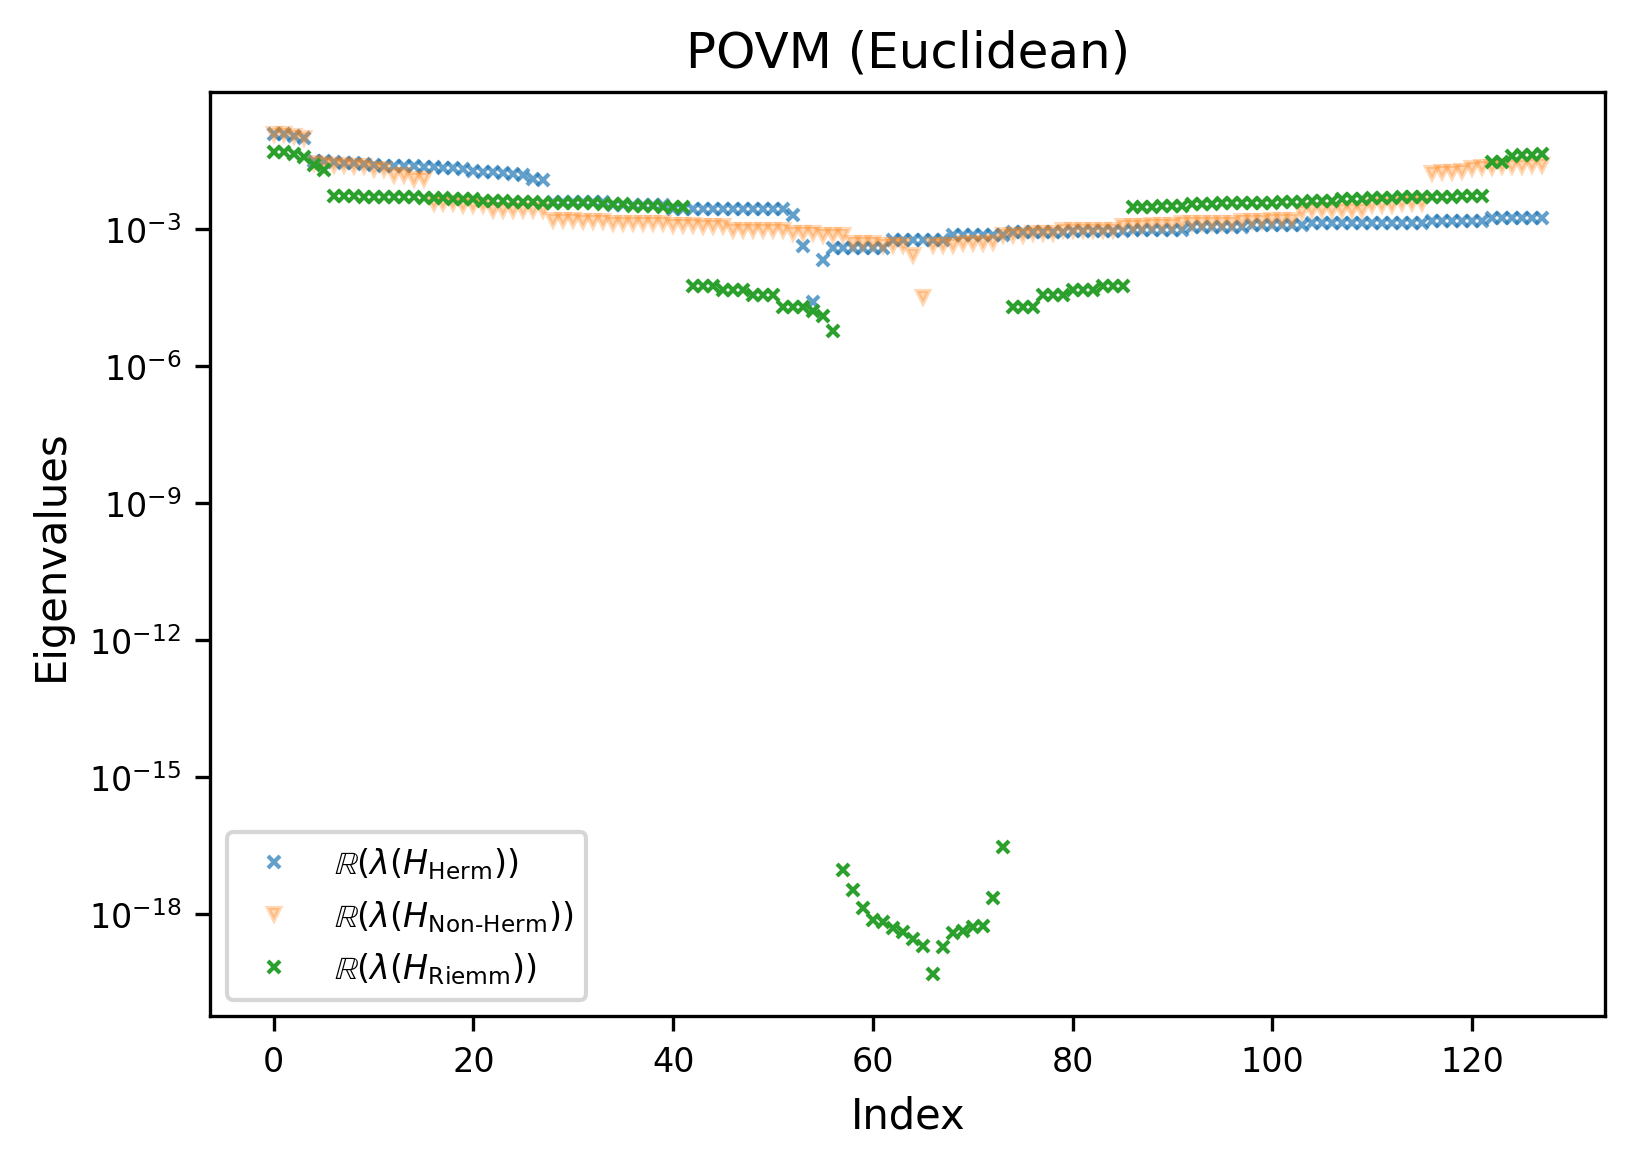

In [75]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("POVM (Euclidean)", fontsize=12)
plt.semilogy(jnp.abs(eeigvals_real_ordered), "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Herm}}) \right)$", alpha=0.7)
plt.semilogy(jnp.abs(eeigvals_real_ordered_nonherm), "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Non-Herm}}) \right)$", alpha=0.3)
plt.plot(jnp.abs(eigvals_real), "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Riemm}}) \right)$")
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [58]:
jnp.linalg.matrix_rank(ehessian_matrix)

Array(128, dtype=int64)

In [59]:
jnp.linalg.matrix_rank(ehessian_matrix_nonherm)

Array(128, dtype=int64)

In [73]:
jnp.linalg.matrix_rank(rhessian_matrix)

Array(111, dtype=int64)

# Hessian (Kraus)

## Euclidean Hessian

In [6]:
type(kraus_tensor_mgst), type(povm_mgst), type(state_mgst), type(prob_matrix), type(indices_list)

(numpy.ndarray,
 jaxlib.xla_extension.ArrayImpl,
 jaxlib.xla_extension.ArrayImpl,
 numpy.ndarray,
 list)

In [13]:
ehessian_mtrx_kraus = compute_euclidean_hessian_kraus(
    kraus_tensor=kraus_tensor_mgst, povm_mgst=povm_mgst, state_mgst=state_mgst, indices_list=indices_list, prob_matrix=prob_matrix
)

In [93]:
# check if they are hermitian
ehessian_mtrx_kraus_adjoint = ehessian_mtrx_kraus.conj().T
jnp.allclose(ehessian_mtrx_kraus, ehessian_mtrx_kraus_adjoint)

Array(True, dtype=bool)

### Hessian orderings

In [100]:
# create hessian with different ordering.
ehessian_mtrx_kraus_herm_order = ehessian_mtrx_kraus.copy()
n_kraus = kraus_tensor_mgst.size

Hxx = ehessian_mtrx_kraus_herm_order[:n_kraus, :n_kraus]
Hxconjx = ehessian_mtrx_kraus_herm_order[:n_kraus, n_kraus:]

# H00
ehessian_mtrx_kraus_herm_order[:n_kraus, :n_kraus] = Hxconjx
# H01
ehessian_mtrx_kraus_herm_order[:n_kraus, n_kraus:] = Hxx
# H11
ehessian_mtrx_kraus_herm_order[n_kraus:, n_kraus:] = Hxconjx.conj()
# H10
ehessian_mtrx_kraus_herm_order[n_kraus:, :n_kraus] = Hxx.conj()

# Check if this new ordering is hermitian
ehessian_mtrx_kraus_herm_order_adjoint = ehessian_mtrx_kraus_herm_order.conj().T
jnp.allclose(ehessian_mtrx_kraus_herm_order, ehessian_mtrx_kraus_herm_order_adjoint)


Array(False, dtype=bool)

In [104]:
# Compute the eigenvalues
eigvals_kraus_og_order = jnp.linalg.eigvals(ehessian_mtrx_kraus)
eigvals_kraus_herm_order = jnp.linalg.eigvals(ehessian_mtrx_kraus_herm_order)
eigvals_kraus_og_order_real = eigvals_kraus_og_order.real
eigvals_kraus_herm_order_real = eigvals_kraus_herm_order.real
eigvals_kraus_og_order_imag = eigvals_kraus_og_order.imag
eigvals_kraus_herm_order_imag = eigvals_kraus_herm_order.imag

In [105]:
# are both imaginary parts close to zero?
jnp.linalg.norm(eigvals_kraus_og_order_imag), jnp.linalg.norm(eigvals_kraus_herm_order_imag)

(Array(2.76240155e-16, dtype=float64), Array(5.3002789e-12, dtype=float64))

2025-12-15 12:04:13,227 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 12:04:13,232 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 12:04:13,289 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 12:04:13,294 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


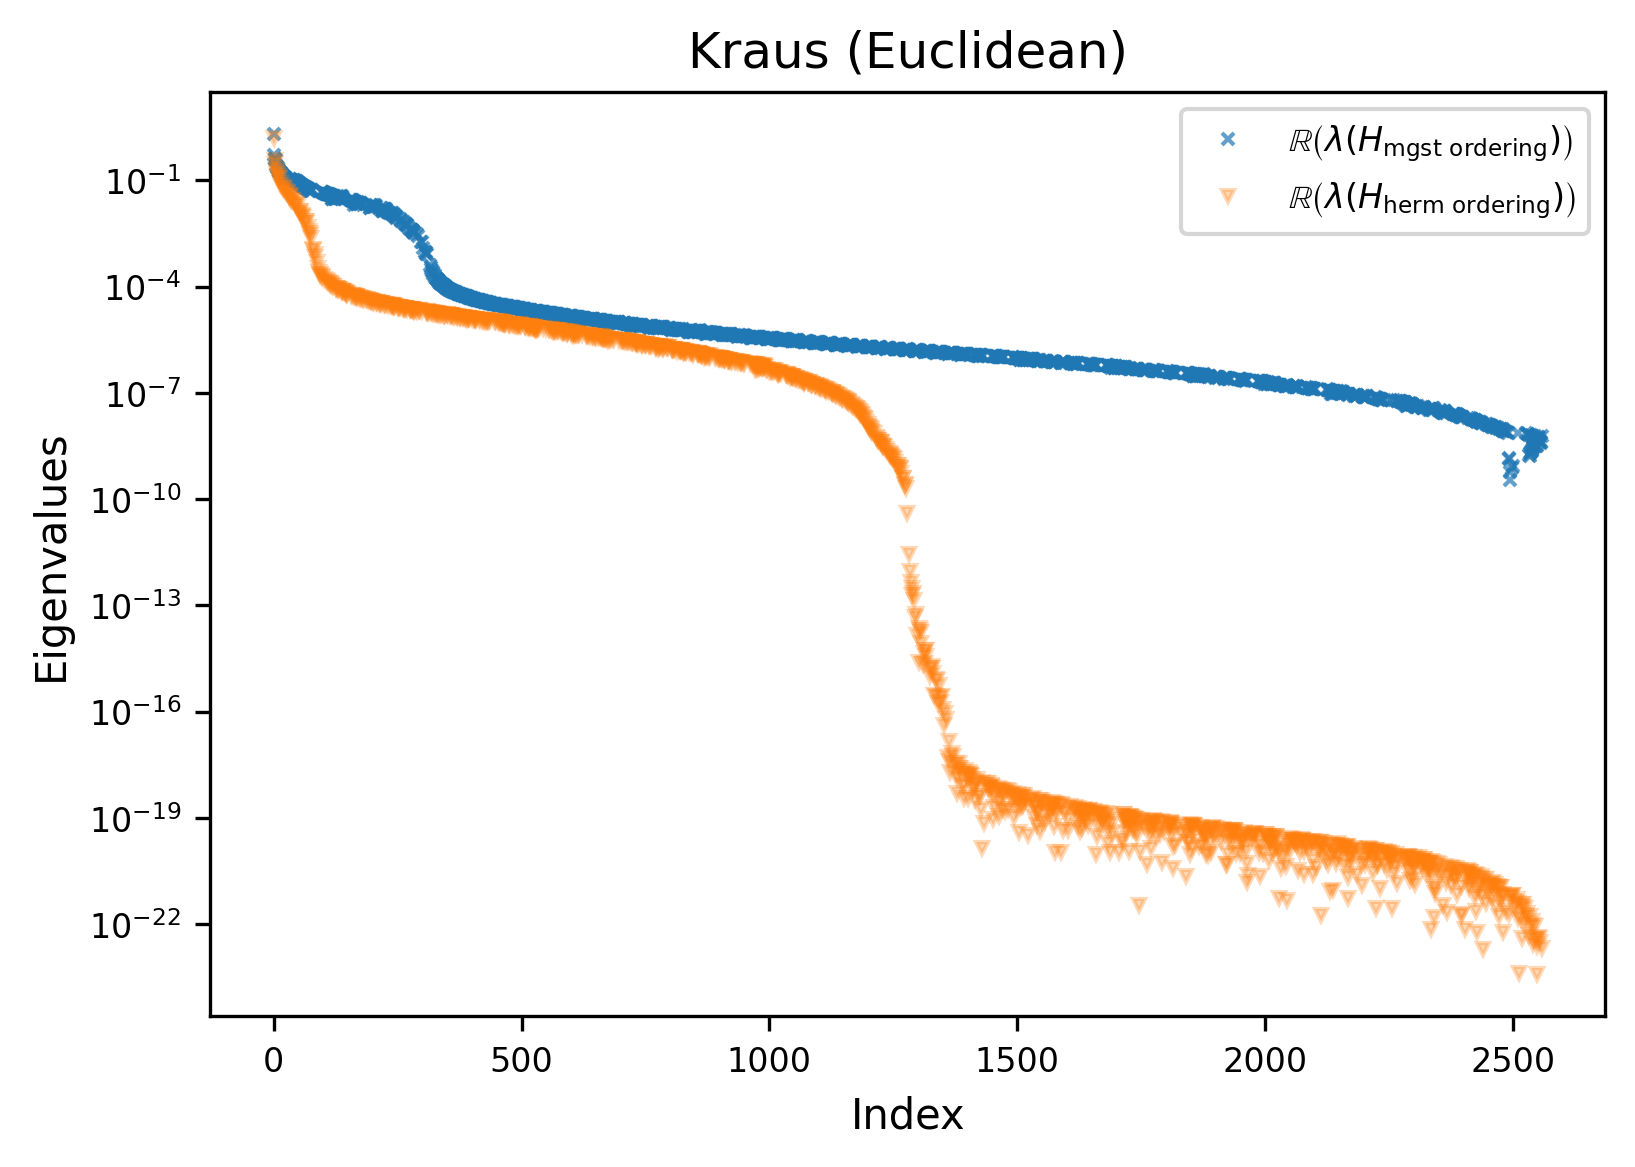

In [111]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus (Euclidean)", fontsize=12)
plt.semilogy(eigvals_kraus_og_order_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{mgst ordering}}) \right)$", alpha=0.7)
plt.semilogy(eigvals_kraus_herm_order_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{herm ordering}}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [109]:
jnp.linalg.matrix_rank(ehessian_mtrx_kraus)

Array(2560, dtype=int64)

## Euclidean derivatives

In [14]:
derivatives_kraus = compute_euclidean_derivatives_kraus(
    kraus_tensor=kraus_tensor_mgst,
    povm_mgst=povm_mgst,
    state_mgst=state_mgst,
    indices_list=indices_list,
    prob_matrix=prob_matrix,
)

In [15]:
derivatives_kraus.keys()

dict_keys(['dK_', 'dM10', 'dM11', 'dd', 'dconjd'])

In [16]:
dM11 = derivatives_kraus['dM11']
dM10 = derivatives_kraus['dM10']
dd = derivatives_kraus['dd']
dconjd = derivatives_kraus['dconjd']
dK_ = derivatives_kraus['dK_']

In [17]:
# Is this a critical point?
jnp.linalg.norm(dK_)/jnp.linalg.norm(kraus_tensor_mgst)

Array(0.00584877, dtype=float64)

In [20]:
# Second derivatives
num_gates, kraus_rank, dim, dim =  kraus_tensor_mgst.shape
dim_sqrd = int(dim**2)
n = kraus_rank * dim
p = dim
vect_dim = n * p
K = kraus_tensor_mgst

Fyconjy = dM11.reshape(num_gates, vect_dim, num_gates, vect_dim) + np.einsum("ijklmnop->ikmojlnp", dconjd).reshape((num_gates, vect_dim, num_gates, vect_dim))
Fyy = dM10.reshape(num_gates, vect_dim, num_gates, vect_dim) + np.einsum("ijklmnop->ikmojlnp", dd).reshape((num_gates, vect_dim, num_gates, vect_dim))

## Computing Riemannian Hessian

In [25]:
fixed_gates = []
rhessian_kraus_mgst = np.zeros((2, num_gates, vect_dim, 2, num_gates, vect_dim)).astype(np.complex128)
G = np.zeros((2, num_gates, vect_dim)).astype(np.complex128)
X = np.einsum("ijkl,ijnm -> iknlm", K, K.conj()).reshape((num_gates, dim_sqrd, dim_sqrd))

for k in range(num_gates):
   # Reshaping into isometry
    Fy = dK_[k].reshape((n, dim))
    Y = K[k].reshape((n, dim))
    # riemannian gradient under canonical metric
    rGrad = Fy.conj() - Y @ Fy.T @ Y

    # saving rgrad for gate k as a vector
    G[0, k, :] = rGrad.reshape(-1)
    # saving (rgrad)* for gate k as a vector
    G[1, k, :] = rGrad.conj().reshape(-1)

    # projector onto orthogonal complement of stiefel manifold. I = X X^dag + X_perp X_perp^dag
    P = np.eye(n) - Y @ Y.T.conj()
    # transpose superoperator
    T = transp(n, dim)
    # Hessian assembly
    # See theorem 1, equation A27
    # This is already the riemannian hessian elements
    H00 = (
        -(np.kron(Y, Y.T)) @ T @ Fyy[k, :, k, :].T
        + Fyconjy[k, :, k, :].T.conj()
        - (np.kron(np.eye(n), Y.T @ Fy)) / 2
        - (np.kron(Y @ Fy.T, np.eye(dim))) / 2
        - (np.kron(P, Fy.T.conj() @ Y.conj())) / 2
    )
    H01 = (
        Fyy[k, :, k, :].T.conj()
        - np.kron(Y, Y.T) @ T @ Fyconjy[k, :, k, :].T
        + (np.kron(Fy.conj(), Y.T) @ T) / 2
        + (np.kron(Y, Fy.T.conj()) @ T) / 2
    )

    # Full hessian on Z and Z*
    # See relation in equation A37 of individual hessian submatrices
    # Riemannian Hessian with correction terms
    rhessian_kraus_mgst[0, k, :, 0, k, :] = H00
    rhessian_kraus_mgst[0, k, :, 1, k, :] = H01 
    rhessian_kraus_mgst[1, k, :, 0, k, :] = H01.conj()
    rhessian_kraus_mgst[1, k, :, 1, k, :] = H00.conj()
    
    # These are the cross terms of the Hessian between different gates.
    for k2 in range(num_gates):
        if k2 != k:
            Yk2 = K[k2].reshape(n, p)
            rhessian_kraus_mgst[0, k2, :, 0, k, :] = Fyconjy[k, :, k2, :].T.conj() - np.kron(Yk2, Yk2.T) @ T @ Fyy[k, :, k2, :].T
            rhessian_kraus_mgst[0, k2, :, 1, k, :] = Fyy[k, :, k2, :].T.conj() - np.kron(Yk2, Yk2.T) @ T @ Fyconjy[k, :, k2, :].T
            rhessian_kraus_mgst[1, k2, :, 0, k, :] = rhessian_kraus_mgst[0, k2, :, 1, k, :].conj()
            rhessian_kraus_mgst[1, k2, :, 1, k, :] = rhessian_kraus_mgst[0, k2, :, 0, k, :].conj()

In [26]:
rhessian_kraus_mgst_mtrx = rhessian_kraus_mgst.reshape(2 * num_gates * vect_dim, 2 * num_gates * vect_dim)

In [27]:
# is the riemannian hessian hermitian?
rhessian_kraus_mgst_mtrx_adjoint = rhessian_kraus_mgst_mtrx.conj().T
jnp.allclose(rhessian_kraus_mgst_mtrx, rhessian_kraus_mgst_mtrx_adjoint)

Array(False, dtype=bool)

## Looking at the Eigen values of the Riemannian Hessian

In [18]:
reigvals_kraus =jnp.linalg.eigvals(rhessian_kraus_mgst_mtrx)
reigvals_kraus_real = reigvals_kraus.real
reigvals_kraus_imag = reigvals_kraus.imag
jnp.linalg.norm(reigvals_kraus_imag), jnp.linalg.norm(reigvals_kraus_real)

(Array(1.6741423e-16, dtype=float64), Array(0.80443168, dtype=float64))

In [173]:
# reigvals_kraus_real_ordered = jnp.sort(reigvals_kraus_real, descending=True)
# eigvals_kraus_og_order_real_ordered = jnp.sort(eigvals_kraus_og_order_real, descending=True)

reigvals_kraus_real_ordered = jnp.sort(jnp.abs(reigvals_kraus_real), descending=True)
eigvals_kraus_og_order_real_ordered = jnp.sort(jnp.abs(eigvals_kraus_og_order_real), descending=True)

In [171]:
eigvals_kraus_og_order_real_ordered.min(), reigvals_kraus_real_ordered.min()

(Array(-0.04829247, dtype=float64), Array(-0.05655572, dtype=float64))

2025-12-15 16:58:47,596 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 16:58:47,602 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 16:58:47,668 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 16:58:47,677 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


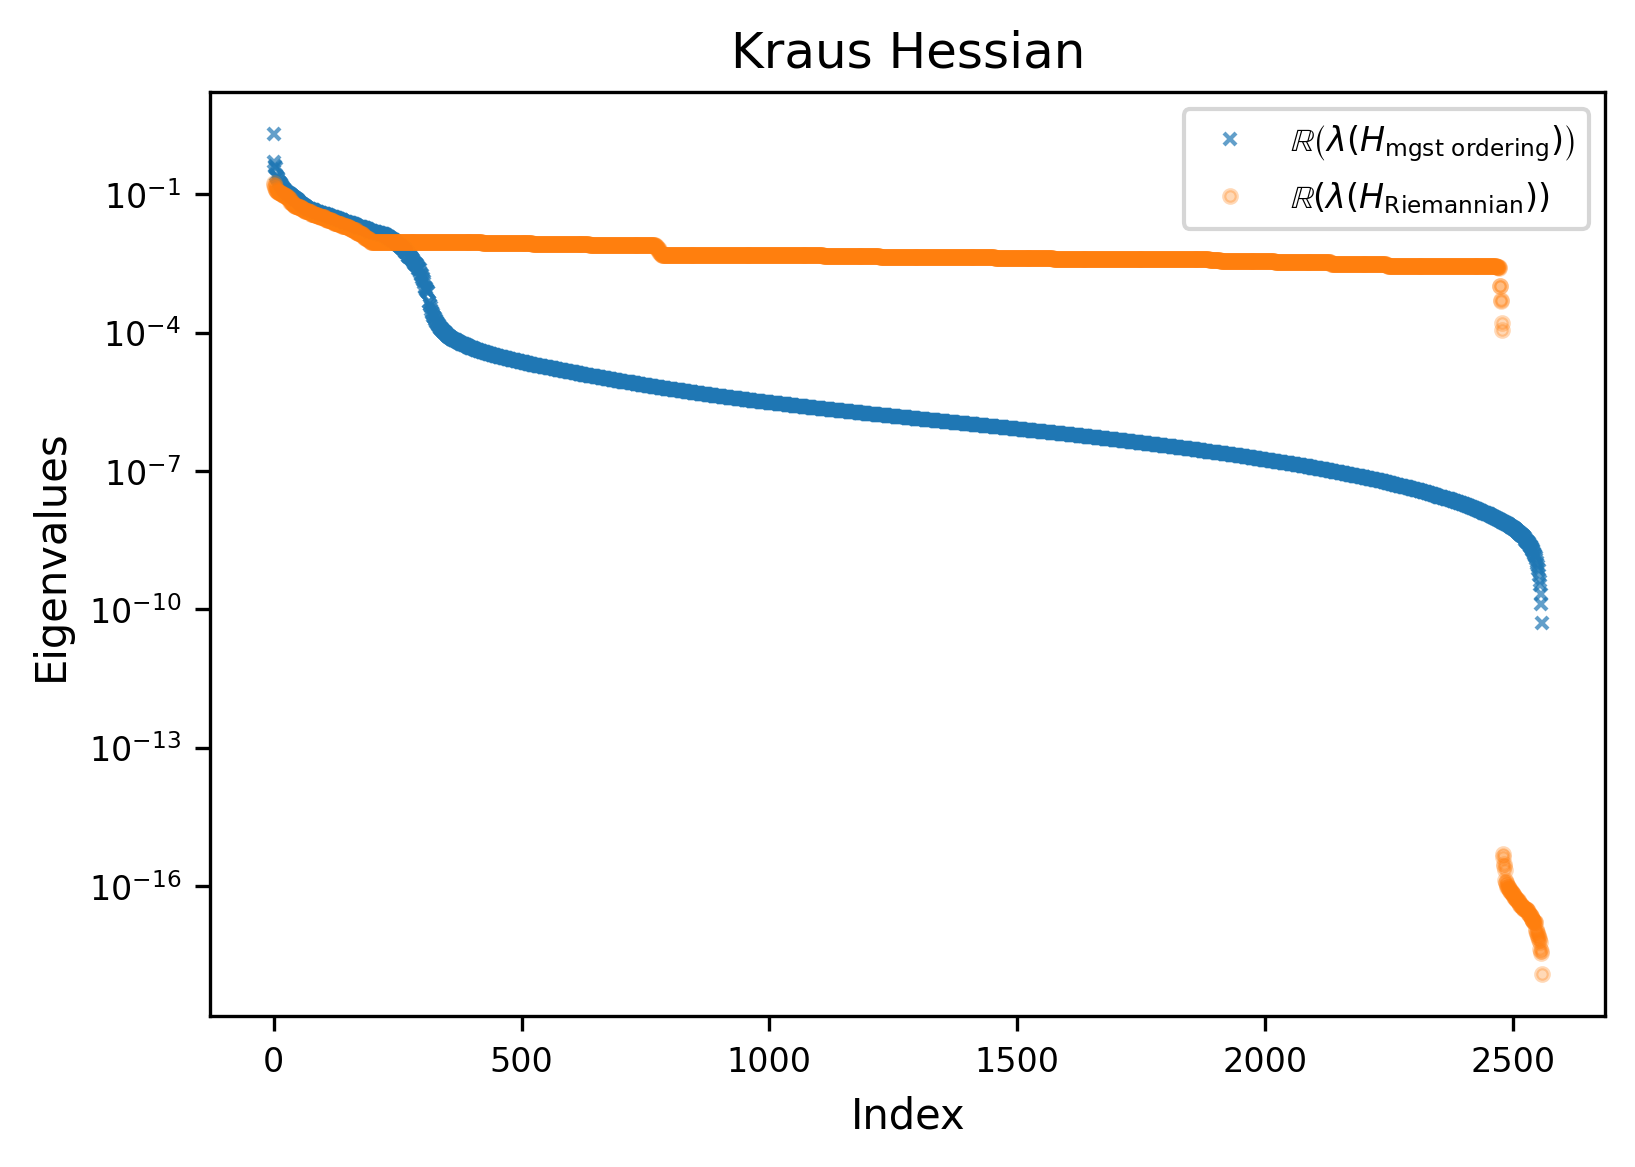

In [174]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus Hessian", fontsize=12)
plt.semilogy(eigvals_kraus_og_order_real_ordered, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{mgst ordering}}) \right)$", alpha=0.7)
# plt.semilogy(jnp.abs(eigvals_kraus_herm_order_real), "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{herm ordering}}) \right)$", alpha=0.3)
plt.plot(reigvals_kraus_real_ordered, "o", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Riemannian}}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [155]:
jnp.linalg.matrix_rank(rhessian_kraus_mgst_mtrx)

Array(2480, dtype=int64)

In [159]:
rhessian_kraus_mgst_mtrx.shape

(2560, 2560)

In [156]:
jnp.linalg.matrix_rank(ehessian_mtrx_kraus_herm_order)

Array(1280, dtype=int64)

In [ ]:
# gauge degrees of freedom here:
dof_kraus = 2560 - 2480
print("dof_kraus:", dof_kraus)

80

In [206]:
# for all kraus tensors I would need this many iterations:
def stiefel_dof_kraus(dim:int, kraus_rank:int, num_gates:int) -> int:
    n, p = kraus_rank * dim, dim
    dof_per_gate = 2 * n * p - p**2
    return dof_per_gate * num_gates

kraus_rank_2q = 16
dim_2q = 2**2
num_gates_2q = 5
dof_2q = stiefel_dof_kraus(dim_2q, kraus_rank_2q, num_gates_2q)

kraus_rank_4q = 4
dim_4q = 2**4
num_gates_4q = 9
dof_4q = stiefel_dof_kraus(dim_4q, kraus_rank_4q, num_gates_4q)

print("DOF 2Q:", dof_2q)
print("DOF 4Q:", dof_4q)

DOF 2Q: 2480
DOF 4Q: 16128


In [207]:
time_hvp_2q = 57.5e-3 # rank 16, 5 gates, 800 gate sequences
time_hvp_4q = 3.99 # rank 4, 9 gates, 2,000 gate sequences
print(f"Time for 2Q Hessian approx: {time_hvp_2q * dof_2q} s")
print(f"Time for 4Q Hessian approx: {time_hvp_4q * dof_4q/3600} h")

Time for 2Q Hessian approx: 142.6 s
Time for 4Q Hessian approx: 17.8752 h


# Conclusions
1. Constructing the Hessian by iterating over all parameters seems complicated. Already with kraus rank 1 and `num_sequences=2000` it would take around 2.5 hours!
2. How many iterations would we need with the spectral density aproach?
    * It seems like an approach is turn the hessian into "G-hermitian".
    *

# Finding the similar matrix that is hermitian

We focus on a single kraus operator for now

In [ ]:
from mGST.utility_functions_comparisons import get_isometry_dimensions_from_tensor, tensor_to_isometry, random_tangent_vector
from mGST.riemannian import riemannian_metric
from mGST.additional_fns import transp
from jax.scipy.linalg import sqrtm

In [29]:
k = 0
rhessian_kraus_mgst_gate_k = rhessian_kraus_mgst[ :, k, :, :, k, :]
print(rhessian_kraus_mgst_gate_k.shape)

rhessian_kraus_mgst_gate_k_mtrx = rhessian_kraus_mgst_gate_k.reshape(2 * vect_dim, 2 * vect_dim)
print(rhessian_kraus_mgst_gate_k_mtrx.shape)

print("Is this hermitian?")
rhessian_kraus_mgst_gate_k_mtrx_adjoint = rhessian_kraus_mgst_gate_k_mtrx.conj().T
print(jnp.allclose(rhessian_kraus_mgst_gate_k_mtrx, rhessian_kraus_mgst_gate_k_mtrx_adjoint))

(2, 256, 2, 256)
(512, 512)
Is this hermitian?
False


In [30]:
n_kraus, p_kraus = get_isometry_dimensions_from_tensor(kraus_tensor_mgst, operator_type='kraus')
print(n_kraus, p_kraus, kraus_tensor_mgst.shape)

kraus_isometry = tensor_to_isometry(kraus_tensor_mgst, n_kraus, p_kraus)
kraus_isometry_k = kraus_isometry[k]
print(kraus_isometry_k.shape)

64 4 (5, 16, 4, 4)
(64, 4)


## G matrix construction

In [32]:
# Create the G matrix that changes to a similar matrix that is hermitian
alpha0, alpha1 = 1, 1/2
x = kraus_isometry_k

def get_lambda_matrix(x, alpha0, alpha1):
    n, _ = x.shape
    Id = jnp.eye(n)
    lambd_matrix = alpha0 * (Id - x @ x.conj().T) + alpha1 * x @ x.conj().T
    return lambd_matrix

def get_gx_matrix(x, alpha0, alpha1, prefactor=1/2):
    _, p = x.shape
    lambd_matrix = get_lambda_matrix(x, alpha0, alpha1)
    Id_vect = jnp.eye(p) # this is the identity acting on the vectorized leg of the input vector
    G00 = jnp.kron(lambd_matrix, Id_vect)
    G11 = jnp.kron(lambd_matrix.conj(), Id_vect)
    zero_mtrx = jnp.zeros_like(G00)
    Gx = prefactor * jnp.block([[G00, zero_mtrx],
                   [zero_mtrx, G11]])
    return Gx

Gx_matrix = get_gx_matrix(kraus_isometry_k, alpha0, alpha1)
Gx_matrix_sqrt = get_gx_matrix(kraus_isometry_k, jnp.sqrt(alpha0), jnp.sqrt(alpha1), prefactor=1/jnp.sqrt(2))

Gx_matrix_inv = get_gx_matrix(kraus_isometry_k, 1/alpha0, 1/alpha1, prefactor=2)
Gx_matrix_inv_sqrt = get_gx_matrix(kraus_isometry_k, 1/jnp.sqrt(alpha0), 1/jnp.sqrt(alpha1), prefactor=jnp.sqrt(2))

In [33]:
jnp.allclose(Gx_matrix, Gx_matrix_sqrt @ Gx_matrix_sqrt)

Array(True, dtype=bool)

In [34]:
jnp.allclose(jnp.eye(Gx_matrix.shape[0]), Gx_matrix @ Gx_matrix_inv)

Array(True, dtype=bool)

In [35]:
jnp.allclose(jnp.eye(Gx_matrix.shape[0]), Gx_matrix_sqrt @ Gx_matrix_inv_sqrt)

Array(True, dtype=bool)

## Failed attempts 

In [36]:
# Change of basis to get a hermitian matrix
H_riemann = rhessian_kraus_mgst_gate_k_mtrx

H_similar = Gx_matrix_sqrt @ H_riemann @ Gx_matrix_inv_sqrt
# are they the same
print(jnp.allclose(H_similar, H_riemann))
# Is the similar matrix euclidean hermitian?
H_similar_adjoint = H_similar.conj().T
print(jnp.allclose(H_similar, H_similar_adjoint))

False
False


In [37]:
# Is the basic property true:
jnp.allclose(Gx_matrix @ H_riemann, H_riemann.conj().T @ Gx_matrix)

Array(False, dtype=bool)

In [38]:
H_riemann.shape, x.shape, Gx_matrix.shape

((512, 512), (64, 4), (512, 512))

## Debugging basic properties

In [39]:
# What about in an inner product sense:
z1 = random_tangent_vector(x = x, seed=45)
z2 = random_tangent_vector(x = x, seed=54)

z1_vec = jnp.concatenate([z1.reshape(-1), z1.conj().reshape(-1)])
z2_vec = jnp.concatenate([z2.reshape(-1), z2.conj().reshape(-1)])

z3_vec = H_riemann @ z2_vec
z4_vec = H_riemann @ z1_vec

z3 = z3_vec[:n_kraus * p_kraus].reshape(n_kraus, p_kraus)
z4 = z4_vec[:n_kraus * p_kraus].reshape(n_kraus, p_kraus)

lhs = riemannian_metric(z1 = z1, z2 = z3, x = x, metric="canonical")
rhs = riemannian_metric(z1 = z4, z2 = z2, x = x, metric="canonical")

In [40]:
# So the Riemannian Hessian is self-adjoint w.r.t. the Riemannian metric
jnp.allclose(lhs, rhs)

Array(True, dtype=bool)

In [41]:
# Is this the same result we obtain using Gx instead?
metric_gx = z1_vec.conj().T @ Gx_matrix @ H_riemann @ z2_vec
jnp.allclose(lhs, metric_gx)

Array(True, dtype=bool)

In [42]:
metric_gx_adjoint = z1_vec.conj().T @ H_riemann.conj().T @ Gx_matrix @ z2_vec
jnp.allclose(metric_gx, metric_gx_adjoint)

Array(True, dtype=bool)

In [43]:
# Is the basic property true:
jnp.allclose(Gx_matrix @ H_riemann, H_riemann.conj().T @ Gx_matrix)

Array(False, dtype=bool)

In [44]:
L = jnp.linalg.cholesky(Gx_matrix)
L_inv = jnp.linalg.inv(L)

In [45]:
test_mtrx = L_inv @ H_riemann @ L_inv.conj().T
test_mtrx_adjoint = test_mtrx.conj().T
jnp.allclose(test_mtrx, test_mtrx_adjoint)

Array(False, dtype=bool)

In [46]:
eigvals_gx = jnp.linalg.eigvals(Gx_matrix)

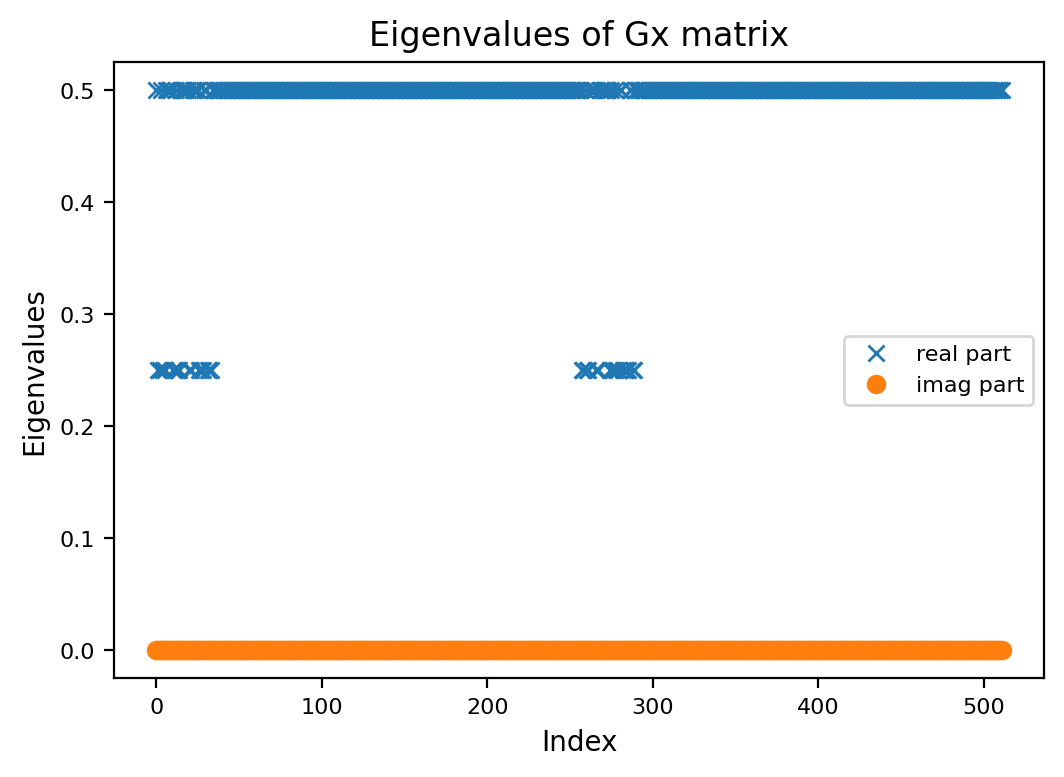

In [47]:
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(eigvals_gx.real, 'x', label='real part')
plt.plot(eigvals_gx.imag, 'o', label='imag part')
plt.title("Eigenvalues of Gx matrix", fontsize=12)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

## Right attempt: Use projection superoperator

In [48]:
# Construct the projection superoperator acting on Z and Z* (vectorized)
def construct_tspace_superop(x):
    n_kraus, p_kraus = x.shape
    vect_size = n_kraus * p_kraus
    
    trans_superop = transp(n_kraus, p_kraus)
    
    Pt_00 = jnp.eye(vect_size) - jnp.kron(x @ x.T.conj(), jnp.eye(dim)) / 2
    Pt_01 = -jnp.kron(x, x.T) @ trans_superop / 2
    return jnp.block([[Pt_00, Pt_01],
                   [Pt_01.conj(), Pt_00.conj()]])

Pt = construct_tspace_superop(x)
Pt.shape

(512, 512)

In [49]:
# Trying again this basic property with the projection superoperator
jnp.allclose(Pt @ Gx_matrix @ H_riemann @ Pt, Pt @ H_riemann.conj().T @ Gx_matrix @ Pt)

Array(True, dtype=bool)

In [50]:
Gt = Pt @ Gx_matrix @ Pt
Ht = Pt @ H_riemann @ Pt

Gt_L = jnp.linalg.cholesky(Gt + 1e-8 * jnp.eye(Gt.shape[0])) # ensure positive definiteness
Gt_L_inv = jnp.linalg.inv(Gt_L)

In [51]:
# just checking basic property
jnp.allclose(Gt, Gt_L @ Gt_L.conj().T)

Array(True, dtype=bool)

In [52]:
M = Gt_L_inv @ Ht @ Gt_L_inv.conj().T
M_adjoint = M.conj().T
jnp.allclose(M, M_adjoint), jnp.linalg.norm(M - M_adjoint)

(Array(False, dtype=bool), Array(0.12772098, dtype=float64))

In [54]:
Gt_half = sqrtm(Gt + 1e-8 * jnp.eye(Gt.shape[0]))
Gt_half_inv = jnp.linalg.inv(Gt_half)

In [55]:
M = Gt_half @ Ht @ Gt_half_inv.conj().T
M_adjoint = M.conj().T
jnp.allclose(M, M_adjoint), jnp.linalg.norm(M - M_adjoint)

(Array(True, dtype=bool), Array(1.27721317e-09, dtype=float64))

From this, we see the right approach is to obtain the similar matrix not just with the metric matrix, but also by using the projection superoperator to obtain 

$H_t = P H P$

and

$Gx_t = P Gx P$

# Stochastic Lanczos method 🎯

In [215]:
# Let's code up the SLQ method for approximating the spectral density of the Riemannian Hessian. 

from mGST.stochastic_lanczos_quadrature import slq_spectral_density, exact_gaussian_spectral_density, slq_rank, generate_nodes_and_weights_for_all_probes, rank_from_density, compute_spectral_resolution, nullity_from_ritz, rank_from_ritz

import jax
jax.config.update("jax_debug_nans", True)
Hessian_matrix = M

def hessian_vector_function(v: jnp.ndarray) -> jnp.ndarray:
    """
    Function to compute the product of the Hessian matrix with a vector.

    Args:
        v (jnp.ndarray): The input vector.

    Returns:
        jnp.ndarray: The result of the Hessian-vector product.
    """
    dim = Hessian_matrix.shape[0]
    vector_z_z_conj = jnp.concatenate([v, v.conj()])
    return (Hessian_matrix @ vector_z_z_conj)[:dim//2]  # Return only the first half corresponding to Z

In [268]:
dim_input = Hessian_matrix.shape[0] // 2
key = jax.random.PRNGKey(0)
min_eigval, max_eigval = (-1e-1, 0.2)
sigma = 5e-4
num_points_grid = 200

# k and m parameters
num_probes = 20
lanczos_order = 50

grid, spectral_density, sigma_norm = slq_spectral_density(
    hvp=hessian_vector_function,
    dim=dim_input,
    key=key,
    num_probes_k=num_probes,
    lanczos_order_m=lanczos_order,
    num_points_grid=num_points_grid,
    min_eigval=min_eigval,
    max_eigval=max_eigval,
    reorth=True,
    sigma=sigma,
    normalize_spectral_density=True,
)

SLQ probe 1/20
SLQ probe 2/20
SLQ probe 3/20
SLQ probe 4/20
SLQ probe 5/20
SLQ probe 6/20
SLQ probe 7/20
SLQ probe 8/20
SLQ probe 9/20
SLQ probe 10/20
SLQ probe 11/20
SLQ probe 12/20
SLQ probe 13/20
SLQ probe 14/20
SLQ probe 15/20
SLQ probe 16/20
SLQ probe 17/20
SLQ probe 18/20
SLQ probe 19/20
SLQ probe 20/20
σ used: 5.00e-04


## Testing the nodes and weights properies

In [179]:
nodes_all_probes, weights_all_probes = generate_nodes_and_weights_for_all_probes(hvp=hessian_vector_function, dim=dim_input, key=key, num_probes_k=num_probes, lanczos_order_m=lanczos_order, reorth=True, verbose=True)

SLQ probe 1/20
SLQ probe 2/20
SLQ probe 3/20
SLQ probe 4/20
SLQ probe 5/20
SLQ probe 6/20
SLQ probe 7/20
SLQ probe 8/20
SLQ probe 9/20
SLQ probe 10/20
SLQ probe 11/20
SLQ probe 12/20
SLQ probe 13/20
SLQ probe 14/20
SLQ probe 15/20
SLQ probe 16/20
SLQ probe 17/20
SLQ probe 18/20
SLQ probe 19/20
SLQ probe 20/20


### Normalization of weights

In [189]:
nodes_all_probes = jnp.array(nodes_all_probes)
weights_all_probes = jnp.array(weights_all_probes)
jnp.sum(weights_all_probes, axis=1), nodes_all_probes.shape

(Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1.], dtype=float64),
 (20, 50))

In [622]:
eps_ritz = 2.9e-3
nullity_mean, nullity_std, mean_frac, std_frac = nullity_from_ritz(nodes_all_probes=nodes_all_probes, weights_all_probes=weights_all_probes, eps=eps_ritz, dim=dim_input)
nullity_mean

Array(9.66012305, dtype=float64)

In [623]:
rank_mean, rank_std, mean_frac, std_frac = rank_from_ritz(nodes_all_probes=nodes_all_probes, weights_all_probes=weights_all_probes, eps=eps_ritz, dim=dim_input)
rank_mean, dim_input, rank_mean + nullity_mean, rank_mean * 2

(Array(246.33987695, dtype=float64),
 256,
 Array(256., dtype=float64),
 Array(492.6797539, dtype=float64))

## Look at eigenvalues

In [580]:
# What about the actual eigenspectrum of these matrices 
eigenvals_hermitian = jnp.linalg.eigvals(Hessian_matrix)
eigenvals_rhessian = jnp.linalg.eigvals(H_riemann)

In [60]:
# Are the eigenvalues the same?
print("Are the hermitan and riemannian eigenvalues equal?:", jnp.allclose(eigenvals_hermitian, eigenvals_rhessian))

# Are they both fully real at least?
eigvals_hermitian_imag = eigenvals_hermitian.imag
eigvals_riemannian_imag = eigenvals_rhessian.imag
print(f"Hermitian-Imag norm: {jnp.linalg.norm(eigvals_hermitian_imag)}")
print(f"Riemannian-Imag norm: {jnp.linalg.norm(eigvals_riemannian_imag)}")
# So they are fully real at least ✅

# How about we order the real parts.
eigenvals_hermitian_real = jnp.sort(eigenvals_hermitian.real)
eigenvals_riemannian_real = jnp.sort(eigenvals_rhessian.real)

print("Close real sorted?", jnp.allclose(eigenvals_hermitian_real, eigenvals_riemannian_real))

# By how much is the difference?
norm_hermitian_eigvals = jnp.linalg.norm(eigenvals_hermitian)
norm_riemannian_eigvals = jnp.linalg.norm(eigenvals_rhessian)

print(f"Norm Hermitian: {norm_hermitian_eigvals}")
print(f"Norm Riemannian: {norm_riemannian_eigvals}")
jnp.linalg.norm(eigenvals_hermitian_real - eigenvals_riemannian_real) / norm_riemannian_eigvals

Are the hermitan and riemannian eigenvalues equal?: False
Hermitian-Imag norm: 6.373056653952717e-14
Riemannian-Imag norm: 5.4842053315387205e-17
Close real sorted? True
Norm Hermitian: 0.3580628368200021
Norm Riemannian: 0.35806283682000817


Array(4.03328011e-13, dtype=float64)

In [61]:
max_eigval_exact = jnp.max(eigenvals_hermitian.real)
min_eigval_exact = jnp.min(eigenvals_hermitian.real)
print("Max eigval: ", max_eigval_exact)
print("Min eigval: ", min_eigval_exact)

Max eigval:  0.16491074960311594
Min eigval:  -0.04326055115679027


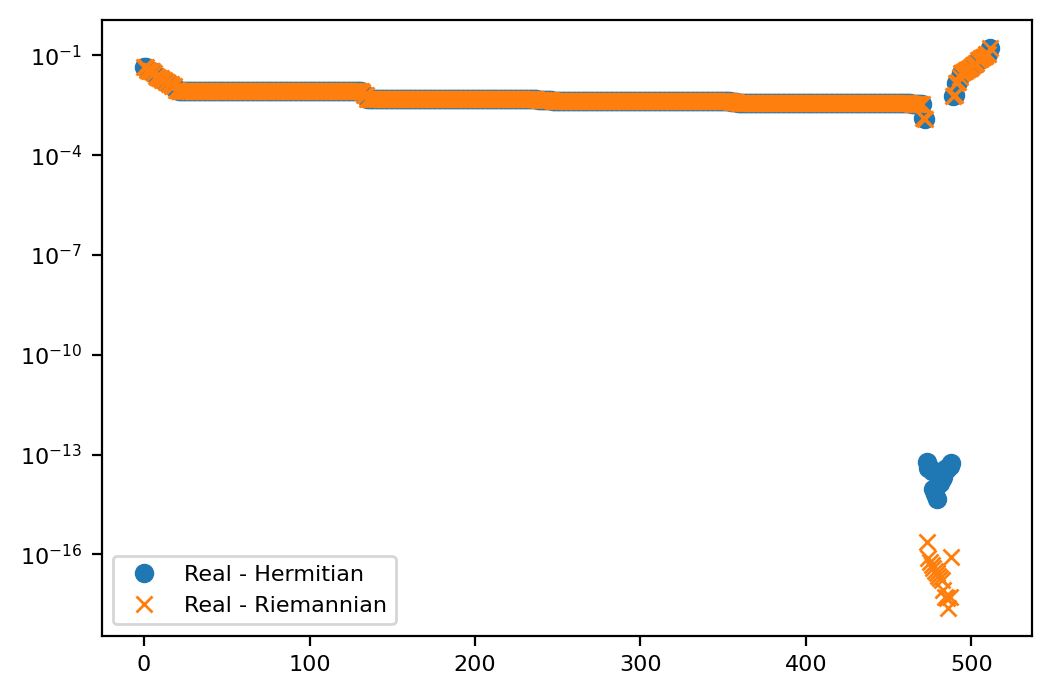

In [283]:
plt.figure(figsize=(6, 4), dpi=200)
plt.semilogy(jnp.abs(eigenvals_hermitian_real), 'o',label="Real - Hermitian")
plt.plot(jnp.abs(eigenvals_riemannian_real), 'x', label="Real - Riemannian")
# plt.plot(eigenvals_hermitian.imag, 'o',label="Imag - Hermitian")
# plt.plot(eigenvals_rhessian.imag, 'x', label="Imag - Riemannian")
plt.legend()

## Verify spectral density

In [269]:
# Verify normalization
dx = grid[1] - grid[0]
print(jnp.sum(spectral_density * dx) , dx)

# Estimation of the trace
mean_slq = jnp.sum(grid * spectral_density) * dx # not entirely sure how this approximates the trace?
trace_exact = jnp.trace(Hessian_matrix) / (2 * dim_input) # the extra 2 because is the actual dimension of H
mean_slq, trace_exact

1.0 0.0015075376884422093


(Array(-0.00307638, dtype=float64),
 Array(-0.00293904-1.74446766e-17j, dtype=complex128))

In [270]:
# Compute the exact spectral density using the analytical formula of the Gaussian and spectral density convoluted
spectral_density_exact = exact_gaussian_spectral_density(eigenvals_hermitian_real, grid, sigma_norm)

In [271]:
hist, bin_edges = jnp.histogram(
    eigenvals_hermitian_real,
    bins=100,
    density=True
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

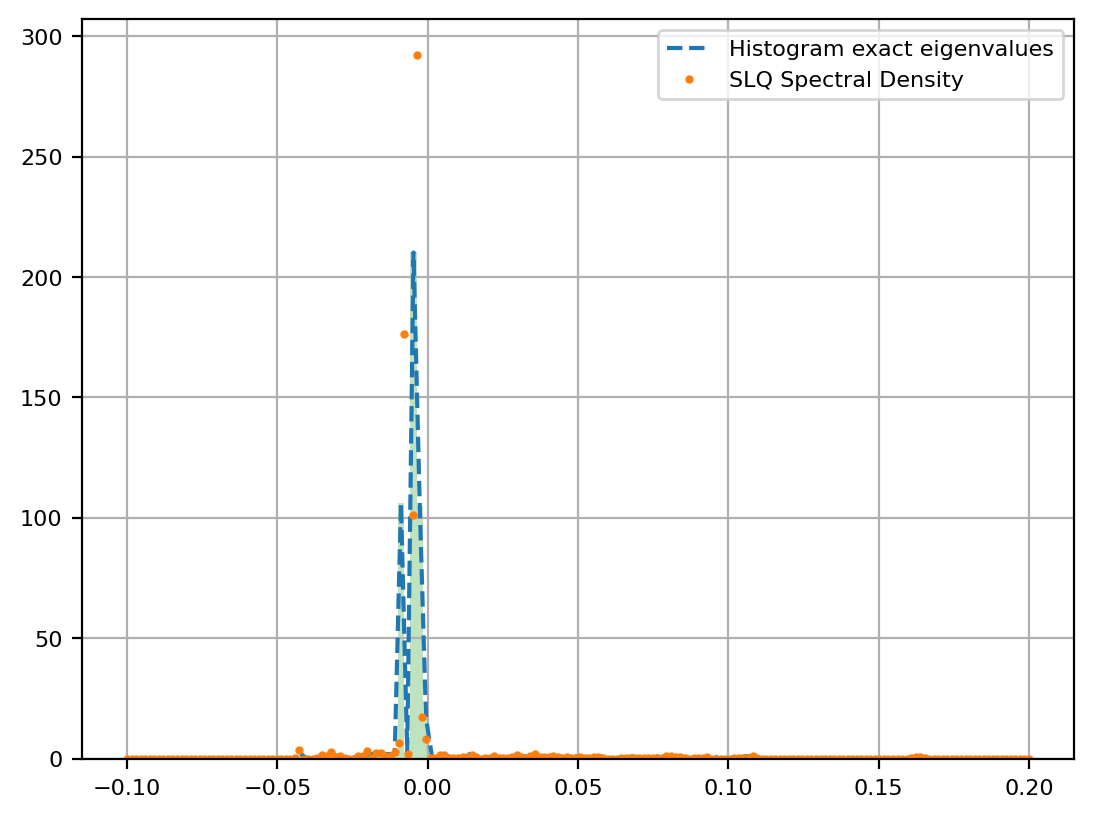

In [508]:
plt.figure(dpi=200)
plt.plot(bin_centers, hist, "--", label="Histogram exact eigenvalues")
plt.plot(grid, spectral_density, 'o', markersize=2,label='SLQ Spectral Density')
# plt.stairs(hist, bin_edges)
plt.hist(eigenvals_hermitian_real, bins=100, density=True, alpha=0.3,)
# plt.plot(grid, spectral_density_exact, '--', label="Exact KDE")
plt.legend()
plt.grid()
plt.show()

### Error norms

In [273]:
# Compute the L1 and L2 norm errors between the SLQ and the "exact" Gaussian spectral density
dx = grid[1] - grid[0]
l1_error = jnp.sum(jnp.abs(spectral_density - spectral_density_exact)) * dx
print(f"L1 error: {l1_error}")

l2_error = jnp.sqrt(jnp.sum((spectral_density - spectral_density_exact)**2) * dx)
print(f"L2 error: {l2_error}")
# It seems like these values are to be expected since a slight shift in the peaks would make a big difference in the norm errors.

L1 error: 0.20728320606159636
L2 error: 1.8695597360332847


In [274]:
norm_slq = jnp.sum(spectral_density) * dx
if not abs(norm_slq - 1.0) < 1e-3:
    print(f"Wrong SLQ norm. Actual value: {norm_slq}")
norm_exact = jnp.sum(spectral_density_exact) * dx
# Not exactly normalized!
if not abs(norm_exact - 1.0) < 1e-3:
    print(f"Wrong exact norm. Actual value: {norm_exact}")


Wrong exact norm. Actual value: 1.0287763081353587


In [275]:
# Wasserstein distance:
0.01 / sigma_norm

20.0

## CDF

In [276]:
def cdf_from_density(eigvals_grid, spectral_density):
    dx = eigvals_grid[1] - eigvals_grid[0]
    return jnp.cumsum(spectral_density) * dx

cdf_exact = cdf_from_density(grid, spectral_density_exact)
cdf_slq   = cdf_from_density(grid, spectral_density)

cdf_linf = jnp.max(jnp.abs(cdf_exact - cdf_slq))
cdf_l2   = jnp.sqrt(jnp.mean((cdf_exact - cdf_slq)**2))

print(f"CDF error inf: {cdf_linf}")
print(f"CDF error L2: {cdf_l2}")

CDF error inf: 0.03586271483952719
CDF error L2: 0.023929397860696998


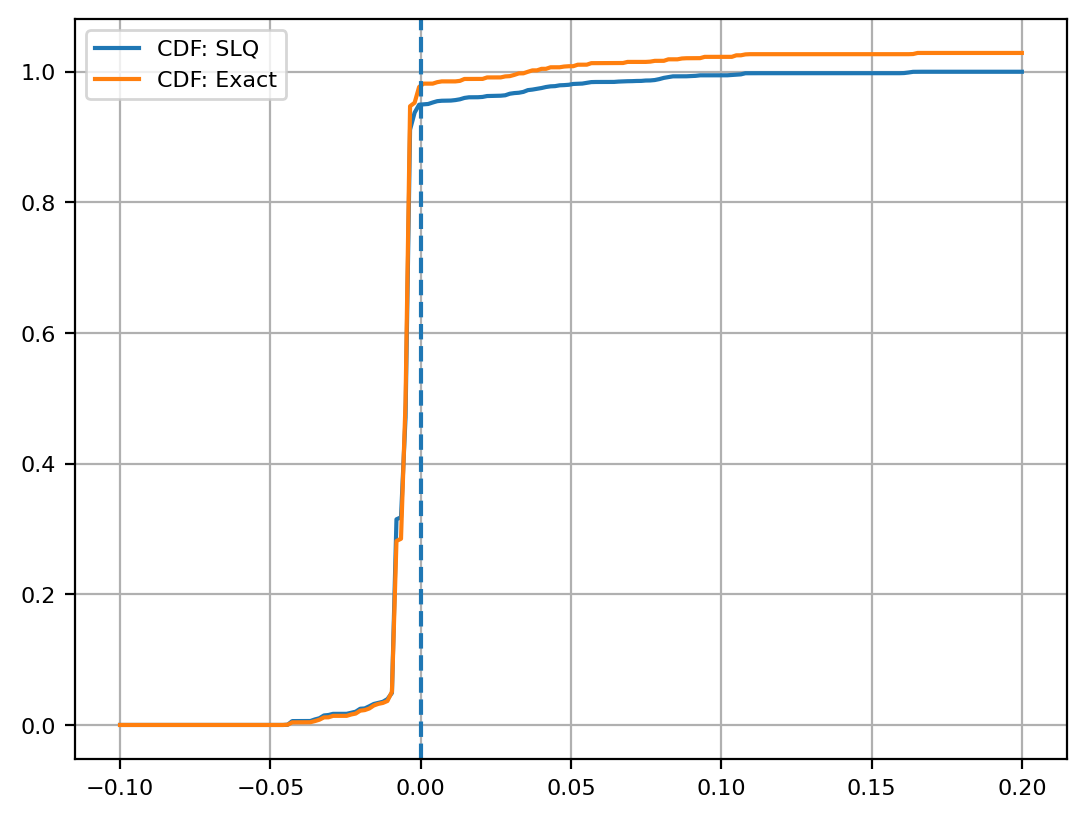

In [277]:
plt.figure(dpi=200)
eps = 1e-6

plt.plot(grid, cdf_slq, label="CDF: SLQ")
plt.plot(grid, cdf_exact, label="CDF: Exact")
plt.axvline(eps, linestyle="--")
plt.legend()
plt.grid()

In [278]:
jnp.sum(spectral_density)

Array(663.33333333, dtype=float64)

# Rank from SLQ

In [584]:
rank_hessian_hermitian = jnp.linalg.matrix_rank(Hessian_matrix, rtol=1e-3)
rank_hessian_riemannian = jnp.linalg.matrix_rank(H_riemann, rtol=1e-3)
print("Rank Hermitian: ", rank_hessian_hermitian)
print("Rank Riemannian: ", rank_hessian_riemannian)

Rank Hermitian:  496
Rank Riemannian:  496


In [576]:
# Compute the exact rank from the eigenvalues we have available.
# Use a smaller epsilon since this is more realistic due to the spectral resolution needed.
new_eps = 1e-3
rank_exact = jnp.sum(jnp.abs(eigenvals_hermitian_real) > new_eps) # internal > comparison produces boolean array, then we just count how many True's are there.
rank_exact

Array(496, dtype=int64)

In [227]:
# eps >= (x_max - x_min) / lanczos_order
spectral_width = max_eigval - min_eigval
spectral_resolution =  spectral_width / lanczos_order
print(f"Eigenvalue range: ({min_eigval, max_eigval}). Lanczos num steps: {lanczos_order}")
print(f"Spectral resolution:{spectral_resolution:.2e}")

Eigenvalue range: ((-0.1, 0.2)). Lanczos num steps: 50
Spectral resolution:6.00e-03


### WRONG

In [83]:
# Can we compute the rank from this spectral density (actually from the cumulative distribution CDF)
# fraction of eigenvalues <= eps
# WRONG ATTEMPT! This sums all the negative values below epsilon.
null_frac = jnp.interp(1e-6, grid, cdf_slq) # we evaluate the higher limit of the integral at eps
nullity_est = dim_input * null_frac
rank_est = dim_input - nullity_est
print(f"Rank estimation: {rank_est}")
null_frac, dim_input

Rank estimation: 13.253936138404185


(Array(0.94822681, dtype=float64), 256)

In [85]:
# WRONG, this also sums all the negative values beloew epsilon. We want everything within epsilon of zero!
# NOTE: this does agree with the spectral density which is good at least (although wrong!)
mask = jnp.abs(grid <= eps)
null_frac = jnp.sum(spectral_density[mask]) * (grid[1] - grid[0])
rank_est = dim_input * (1 - null_frac)
rank_est

Array(13.28695148, dtype=float64)

## Better attempts

In [258]:
rank_est, nullity_est = rank_from_density(grid, spectral_density, eps=10, dim=dim_input)
print("nullity est x 2:", nullity_est * 2)
print("rank est x 2:", rank_est * 2)
print(f"Input dimension x 2: {dim_input * 2}")

nullity est x 2: 9.81079210445399
rank est x 2: 502.189207895546
Input dimension x 2: 512


In [238]:
# Trying to decrease the range to see if this helps.
# However: we are normalizing to this range, so I am not really sure if it makes sense.
min_eigval_focused = -2e-3
max_eigval_focused = 2e-3
lanczos_order_focused = 50

grid_focused, spectral_density_focused, sigma_norm = slq_spectral_density(
    hvp=hessian_vector_function,
    dim=dim_input,
    key=key,
    num_probes_k=num_probes,
    lanczos_order_m=lanczos_order_focused,
    num_points_grid=num_points_grid,
    min_eigval=min_eigval_focused,
    max_eigval=max_eigval_focused,
    reorth=True,
    sigma=sigma,
    normalize_spectral_density=True,
)

SLQ probe 1/20
SLQ probe 2/20
SLQ probe 3/20
SLQ probe 4/20
SLQ probe 5/20
SLQ probe 6/20
SLQ probe 7/20
SLQ probe 8/20
SLQ probe 9/20
SLQ probe 10/20
SLQ probe 11/20
SLQ probe 12/20
SLQ probe 13/20
SLQ probe 14/20
SLQ probe 15/20
SLQ probe 16/20
SLQ probe 17/20
SLQ probe 18/20
SLQ probe 19/20
SLQ probe 20/20
σ used: 4.00e-04


In [239]:
compute_spectral_resolution(min_eigval=min_eigval_focused, max_eigval=max_eigval_focused, lanczos_num_steps=50)

8e-05

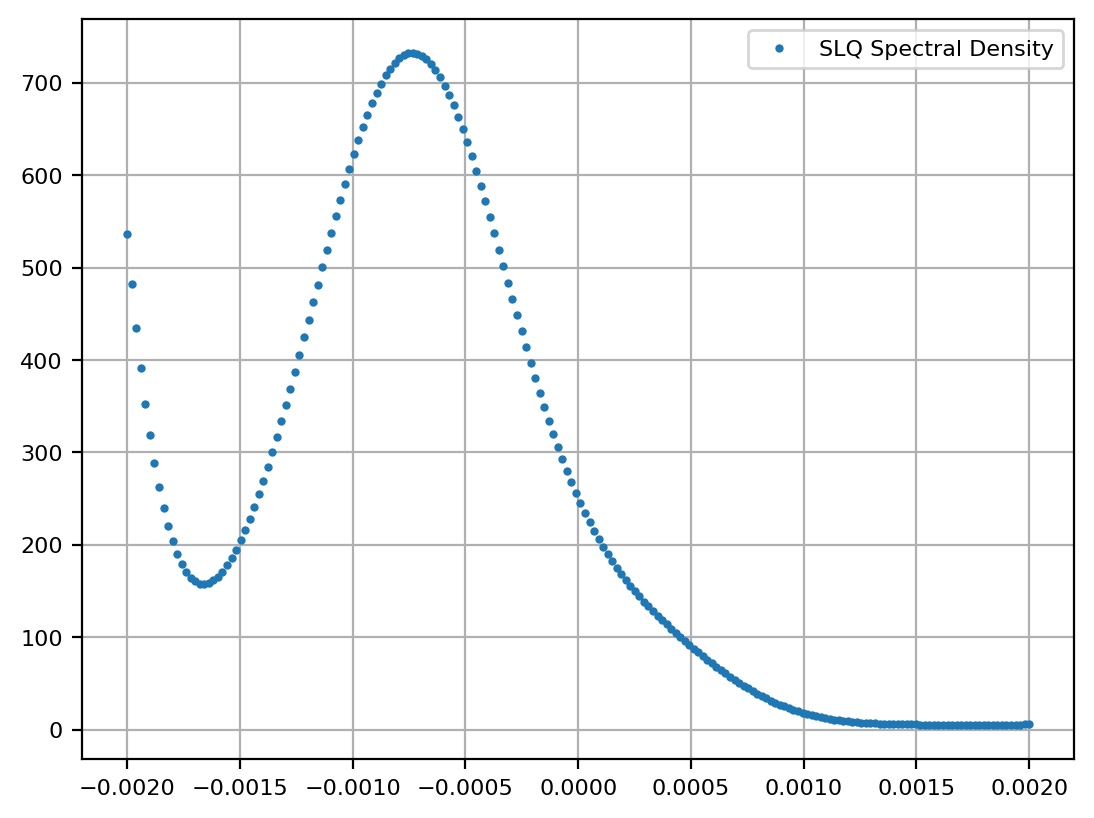

In [240]:
plt.figure(dpi=200)
plt.plot(grid_focused, spectral_density_focused, 'o', markersize=2,label='SLQ Spectral Density')
plt.legend()
plt.grid()
plt.show()

In [245]:
rank_est_focused, null_est_focused = rank_from_density(grid_focused, spectral_density_focused, eps=1e-3, dim=dim_input)
rank_est_focused * 2, null_est_focused

(Array(168.01878177, dtype=float64), Array(171.99060911, dtype=float64))

In [209]:
# Attempt using the rank compuation directly from the Ritz values using an estimator 
# sum_{\abs{\lambda_i} \leq \epsilon} w_i
eps_test = 1e-3
num_probes_test = 20
lanczos_order_test = 200
    
rank_and_nullity_test = slq_rank(
    hvp=hessian_vector_function, dim=dim_input, key=key, eps=eps_test,
    num_probes_k=num_probes_test, lanczos_order_m=lanczos_order_test, 
    reorth=True, verbose=True, use_nullity=False
)

SLQ probe 1/20
SLQ probe 2/20
SLQ probe 3/20
SLQ probe 4/20
SLQ probe 5/20
SLQ probe 6/20
SLQ probe 7/20
SLQ probe 8/20
SLQ probe 9/20
SLQ probe 10/20
SLQ probe 11/20
SLQ probe 12/20
SLQ probe 13/20
SLQ probe 14/20
SLQ probe 15/20
SLQ probe 16/20
SLQ probe 17/20
SLQ probe 18/20
SLQ probe 19/20
SLQ probe 20/20


In [211]:
rank_and_nullity_test_2 = slq_rank(
    hvp=hessian_vector_function, dim=dim_input, key=key, eps=eps_test,
    num_probes_k=num_probes_test, lanczos_order_m=lanczos_order_test, 
    reorth=True, verbose=True, use_nullity=False
)

SLQ probe 1/20
SLQ probe 2/20
SLQ probe 3/20
SLQ probe 4/20
SLQ probe 5/20
SLQ probe 6/20
SLQ probe 7/20
SLQ probe 8/20
SLQ probe 9/20
SLQ probe 10/20
SLQ probe 11/20
SLQ probe 12/20
SLQ probe 13/20
SLQ probe 14/20
SLQ probe 15/20
SLQ probe 16/20
SLQ probe 17/20
SLQ probe 18/20
SLQ probe 19/20
SLQ probe 20/20


In [212]:
rank_and_nullity_test_2

{'rank': (Array(1.26620306, dtype=float64), Array(5.95481728, dtype=float64)),
 'nullity': (Array(254.73379694, dtype=float64),
  Array(5.95481728, dtype=float64))}

In [210]:
rank_and_nullity_test

{'rank': (Array(253.24061223, dtype=float64), Array(1.8666866, dtype=float64)),
 'nullity': (Array(2.75938777, dtype=float64),
  Array(1.8666866, dtype=float64))}

In [168]:
rank_and_nullity_test

{'rank': (Array(255.98620306, dtype=float64),
  Array(0.23516663, dtype=float64)),
 'nullity': (Array(0.01379694, dtype=float64),
  Array(0.23516663, dtype=float64))}

In [169]:
255.986 * 2

511.972

In [160]:
rank_and_nullity_test

{'rank': (Array(254.82485296, dtype=float64),
  Array(5.81145565, dtype=float64)),
 'nullity': (Array(1.17514704, dtype=float64),
  Array(5.81145565, dtype=float64))}

In [157]:
rank_and_nullity_test

{'rank': (Array(251.29421055, dtype=float64),
  Array(12.71644977, dtype=float64)),
 'nullity': (Array(4.70578945, dtype=float64),
  Array(12.71644977, dtype=float64))}

In [152]:
rank_and_nullity_test

{'rank': (Array(255.94481224, dtype=float64),
  Array(0.46789861, dtype=float64)),
 'nullity': (Array(0.05518776, dtype=float64),
  Array(0.46789861, dtype=float64))}

In [162]:
min_eigval_exact, max_eigval_exact

(Array(-0.04326055, dtype=float64), Array(0.16491075, dtype=float64))

## Attempt with a high number of lanczos steps

In [288]:
compute_spectral_resolution(min_eigval_exact, max_eigval_exact, 500)

Array(0.00041634, dtype=float64)

In [289]:
# How much is enough:
from mGST.stochastic_lanczos_quadrature import compute_required_lanczos_steps
compute_required_lanczos_steps(min_eigval_exact, max_eigval_exact, eps=1e-3)
# It's recommended to do significantly more than these (x3 approx)

Array(208.17130076, dtype=float64)

In [382]:
eps_high = 400

nodes_all_samples, weights_all_samples = generate_nodes_and_weights_for_all_probes(
    hvp=hessian_vector_function,
    dim=dim_input,
    key=key,
    num_probes_k=num_probes,
    lanczos_order_m=eps_high,
    reorth=True,
)

SLQ probe 1/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 2/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 3/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 4/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 5/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 6/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 7/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 8/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 9/20
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 149-iterations ⚠️
SLQ probe 10/20
⚠️ Beta <= 1

In [583]:
num_probes

20

In [383]:
# just checking property about weights
jnp.sum(weights_all_samples) / num_probes # since we actually have sum_{j} weights_{i,j} = 1 for_all i.

Array(1., dtype=float64)

In [585]:
rank_mean_high, rank_std_high, *_ = rank_from_ritz(nodes_all_probes=nodes_all_samples, weights_all_probes=weights_all_samples, eps=1e-3, dim=dim_input)
rank_mean_high, rank_std_high, 2 * rank_mean_high

(Array(253.24061223, dtype=float64),
 Array(1.8666866, dtype=float64),
 Array(506.48122446, dtype=float64))

In [472]:
from mGST.stochastic_lanczos_quadrature import smoothened_density_from_nodes_and_weights

min_eigval_test = min_eigval
max_eigval_test = max_eigval
num_points_grid_test = 500

grid_high_sigma_5e3, spectral_density_high_sigma_5e3, sigma_5e3 = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples,
      weights_all_probes=weights_all_samples,
      num_points_grid=num_points_grid_test,
      sigma=5e-3,
      min_eigval=min_eigval_test,
      max_eigval=max_eigval_test,
      normalize=False,
    )

grid_high_normalized_sigma_5e3, spectral_density_high_normalized_sigma_5e3, sigma_5e3 = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples,
      weights_all_probes=weights_all_samples,
      num_points_grid=num_points_grid_test,
      sigma=5e-3,
      min_eigval=min_eigval_test,
      max_eigval=max_eigval_test,
      normalize=True,
    )

σ used: 5.00e-03
σ used: 5.00e-03


In [532]:
grid_high_sigma_5e4, spectral_density_high_sigma_5e4, sigma_5e4 = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples,
      weights_all_probes=weights_all_samples,
      num_points_grid=num_points_grid_test,
      sigma=1e-4,
      min_eigval=min_eigval_test,
      max_eigval=max_eigval_test,
      normalize=False,
    )

grid_high_normalized_sigma_5e4, spectral_density_high_normalized_sigma_5e4, sigma_5e4 = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples,
      weights_all_probes=weights_all_samples,
      num_points_grid=num_points_grid_test,
      sigma=1e-4,
      min_eigval=min_eigval_test,
      max_eigval=max_eigval_test,
      normalize=True,
    )

σ used: 1.00e-04
σ used: 1.00e-04


In [520]:
grid_high_sigma_1e5, spectral_density_high_sigma_1e5, sigma_1e5 = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples,
      weights_all_probes=weights_all_samples,
      num_points_grid=num_points_grid_test,
      sigma=1e-5,
      min_eigval=min_eigval_test,
      max_eigval=max_eigval_test,
      normalize=False,
    )

grid_high_normalized_sigma_1e5, spectral_density_high_normalized_sigma_1e5, sigma_1e5 = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples,
      weights_all_probes=weights_all_samples,
      num_points_grid=num_points_grid_test,
      sigma=1e-5,
      min_eigval=min_eigval_test,
      max_eigval=max_eigval_test,
      normalize=True,
    )

σ used: 1.00e-05
σ used: 1.00e-05


In [586]:
grid_high = grid_high_normalized_sigma_5e4
dx = grid_high[1] - grid_high[0]
trace_exact = jnp.trace(Hessian_matrix) / (2 * dim_input) # the extra 2 because is the actual dimension of H
print("Actual Rank: ", rank_hessian_hermitian)
print("Actual Trace:", trace_exact)
trace_from_eigenvalues = jnp.sum(eigenvals_hermitian)/ (2 * dim_input)
print("Are exaxt and eigenvalue trace the same?: ", jnp.allclose(trace_exact, trace_from_eigenvalues))

Actual Rank:  496
Actual Trace: (-0.0029390389609498684-1.7444676635926818e-17j)
Are exaxt and eigenvalue trace the same?:  True


In [477]:
rank_high, _ = rank_from_density(grid=grid_high, spectral_density=spectral_density_high_sigma_5e3, eps=1e-3, dim=dim_input)
print("Sigma 5e-3")
print(rank_high * 2)

rank_high_normalized, _ = rank_from_density(grid=grid_high, spectral_density=spectral_density_high_normalized_sigma_5e3, eps=1e-3, dim=dim_input)
print(rank_high_normalized * 2)

Sigma 5e-3
468.6152225292275
468.6152225292279


In [541]:
rank_high, _ = rank_from_density(grid=grid_high, spectral_density=spectral_density_high_sigma_5e4, eps=1e-3, dim=dim_input)
print(f"Sigma {sigma_5e4:.2e}")
print(rank_high * 2)

rank_high_normalized, _ = rank_from_density(grid=grid_high, spectral_density=spectral_density_high_normalized_sigma_5e4, eps=1e-3, dim=dim_input)
print(rank_high_normalized * 2)

Sigma 1.00e-04
504.47752604154965
504.89520347907904


In [522]:
rank_high, _ = rank_from_density(grid=grid_high, spectral_density=spectral_density_high_sigma_1e5, eps=1e-3, dim=dim_input)
print("Sigma 1e-5")
print(rank_high * 2)

rank_high_normalized, _ = rank_from_density(grid=grid_high, spectral_density=spectral_density_high_normalized_sigma_1e5, eps=1e-3, dim=dim_input)
print(rank_high_normalized * 2)

Sigma 1e-5
506.1028497144328
492.68628179986337


In [563]:
# Verify normalization
print("Sigma 5e-3")
print("-------------")
print("* Unormalized")
print("\int rho(t) dt", jnp.sum(spectral_density_high_sigma_5e3 * dx))

# How well do these estimate the trace
mean_slq = jnp.sum(grid_high * spectral_density_high_sigma_5e3) * dx # not entirely sure how this approximates the trace?
print(mean_slq)

print("\n")
# Verify normalization
print("*  Normalized")
print("\int rho(t) dt", jnp.sum(spectral_density_high_normalized_sigma_5e3 * dx))

# How well do these estimate the trace
mean_slq = jnp.sum(grid_high * spectral_density_high_normalized_sigma_5e3) * dx # not entirely sure how this approximates the trace?
print(mean_slq)

Sigma 5e-3
-------------
* Unormalized
\int rho(t) dt 1.0000000000000095
-0.0029841894468816458


*  Normalized
\int rho(t) dt 0.9999999999999999
-0.0029841894468816154


In [566]:
# Verify normalization
print(f"Sigma {sigma_5e4:.2e}")
print("-------------")
print("* Unormalized")
print("\int rho(t) dt", jnp.sum(spectral_density_high_sigma_5e4 * dx))

# How well do these estimate the trace
mean_slq = jnp.sum(grid_high * spectral_density_high_sigma_5e4) * dx # not entirely sure how this approximates the trace?
print(mean_slq)

# Verify normalization

print("\n")
# Verify normalization
print("*  Normalized")
print("\int rho(t) dt", jnp.sum(spectral_density_high_normalized_sigma_5e4 * dx))

# How well do these estimate the trace
mean_slq = jnp.sum(grid_high * spectral_density_high_normalized_sigma_5e4) * dx # not entirely sure how this approximates the trace?
print(mean_slq)

Sigma 1.00e-04
-------------
* Unormalized
\int rho(t) dt 1.0587880928467817
-0.0030382911890508356


*  Normalized
\int rho(t) dt 0.9999999999999999
-0.0028695932732693756


In [567]:
# Verify normalization
print("Sigma 1e-5")
print("-------------")
print("* Unormalized")
print("\int rho(t) dt", jnp.sum(spectral_density_high_sigma_1e5 * dx))

# How well do these estimate the trace
mean_slq = jnp.sum(grid_high * spectral_density_high_sigma_1e5) * dx # not entirely sure how this approximates the trace?
print(mean_slq)

# Verify normalization
print("\n")
print("* Normalized")
print("\int rho(t) dt", jnp.sum(spectral_density_high_normalized_sigma_1e5 * dx))

# How well do these estimate the trace
mean_slq = jnp.sum(grid_high * spectral_density_high_normalized_sigma_1e5) * dx # not entirely sure how this approximates the trace?
print(mean_slq)

Sigma 1e-5
-------------
* Unormalized
\int rho(t) dt 0.30533480008657515
-0.0007925586510507258


* Normalized
\int rho(t) dt 0.9999999999999999
-0.0025957036368799173


In [536]:
spectral_density_exact_high_sigma_5e4 = exact_gaussian_spectral_density(eigenvals_hermitian_real, grid_high, sigma_5e4)

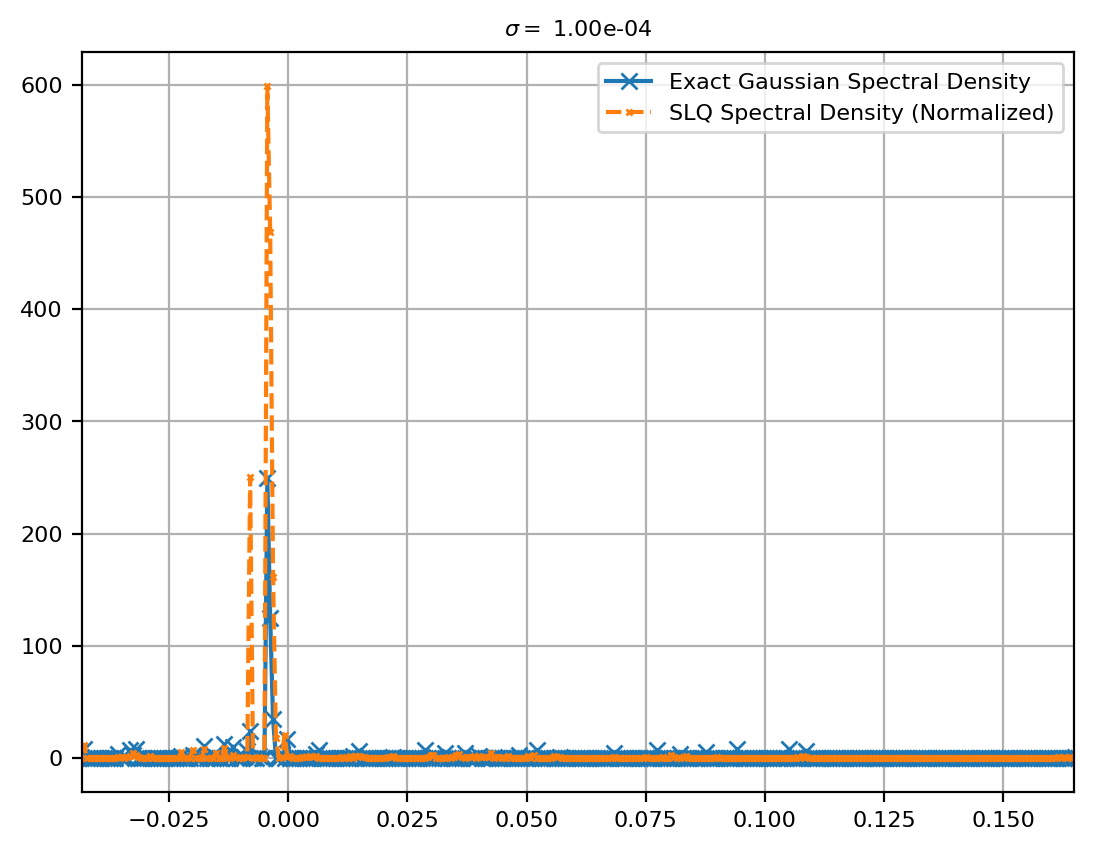

In [582]:
plt.figure(dpi=200)
# plt.plot(bin_centers, hist, "-x", label="Histogram exact eigenvalues")
plt.title(rf"$\sigma =$ {sigma_5e4:.2e}")
plt.plot(grid_high, spectral_density_exact_high_sigma_5e4, '-x', label="Exact Gaussian Spectral Density")
# plt.plot(grid_high, spectral_density_high_sigma_5e4, '--o', markersize=2,label=rf'SLQ Spectral Density')
plt.plot(grid_high, spectral_density_high_normalized_sigma_5e4, '--x', markersize=2,label=rf'SLQ Spectral Density (Normalized)')
plt.legend()
plt.xlim((min_eigval_exact, max_eigval_exact))
plt.grid()
plt.show()

In [511]:
spectral_density_exact_high_sigma_5e3 = exact_gaussian_spectral_density(eigenvals_hermitian_real, grid_high, sigma_5e3)

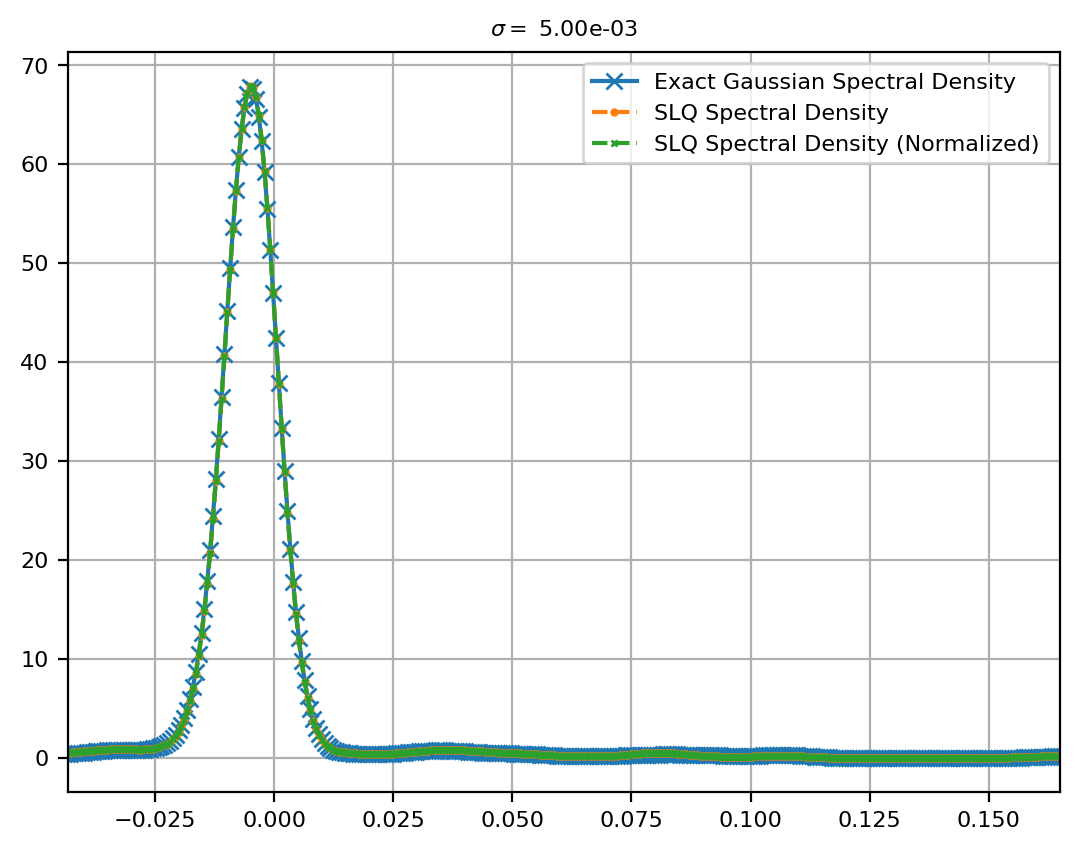

In [547]:
plt.figure(dpi=200)
# plt.plot(bin_centers, hist, "-x", label="Histogram exact eigenvalues")
plt.title(rf"$\sigma =$ {sigma_5e3:.2e}")
plt.plot(grid_high, spectral_density_exact_high_sigma_5e3, '-x', label="Exact Gaussian Spectral Density")
plt.plot(grid_high, spectral_density_high_sigma_5e3, '--o', markersize=2,label=r'SLQ Spectral Density')
plt.plot(grid_high, spectral_density_high_normalized_sigma_5e3, '--x', markersize=2,label=r'SLQ Spectral Density (Normalized)')
plt.legend()
plt.xlim((min_eigval_exact, max_eigval_exact))
plt.grid()
plt.show()

In [524]:
spectral_density_exact_high_sigma_1e5 = exact_gaussian_spectral_density(eigenvals_hermitian_real, grid_high, sigma_1e5)

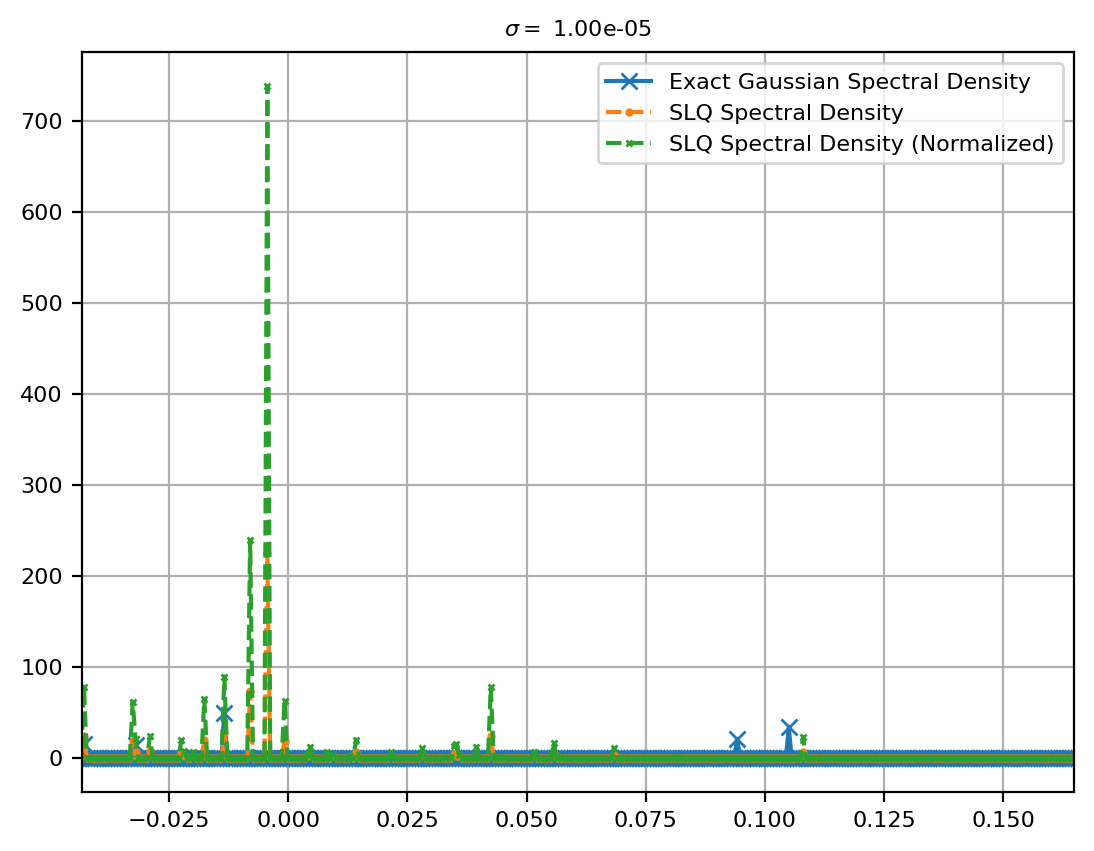

In [557]:
plt.figure(dpi=200)
plt.title(rf"$\sigma =$ {sigma_1e5:.2e}")
plt.plot(grid_high, spectral_density_exact_high_sigma_1e5, '-x', label="Exact Gaussian Spectral Density")
plt.plot(grid_high, spectral_density_high_sigma_1e5, '--o', markersize=2,label='SLQ Spectral Density')
plt.plot(grid_high, spectral_density_high_normalized_sigma_1e5, '--x', markersize=2,label='SLQ Spectral Density (Normalized)')
plt.legend()
plt.xlim((min_eigval_exact, max_eigval_exact))
plt.grid()
plt.show()

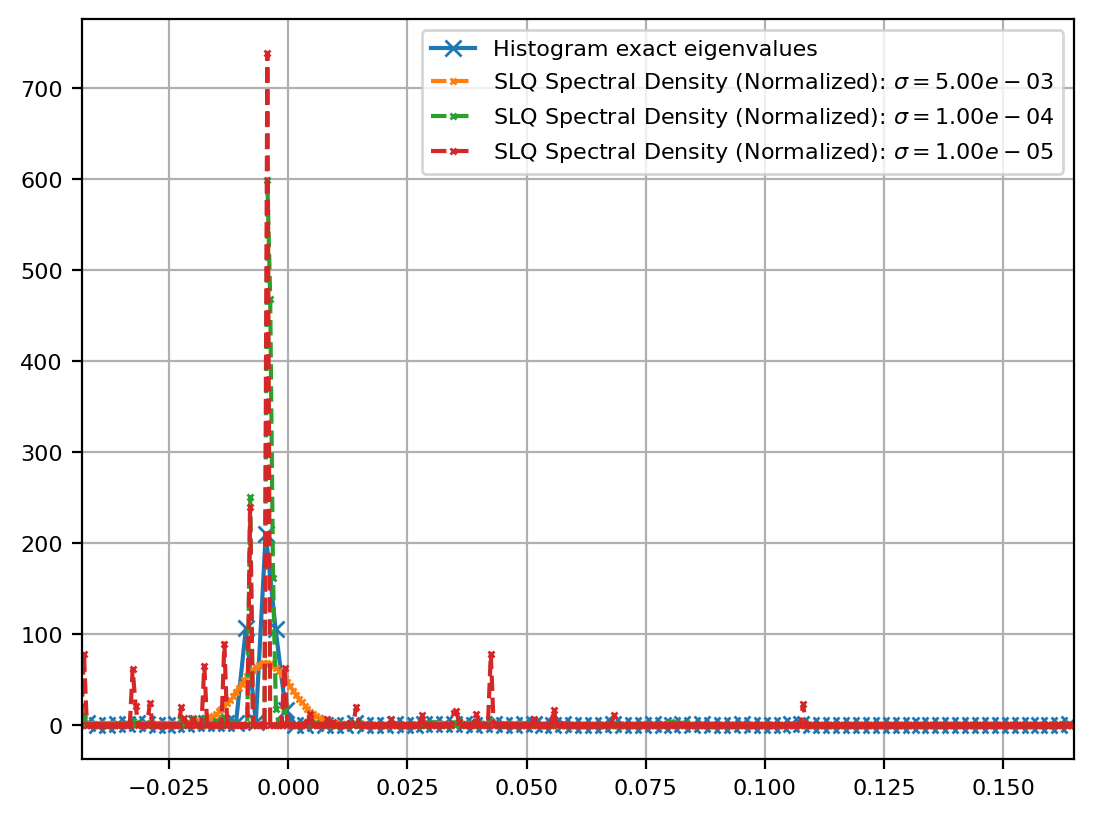

In [556]:
plt.figure(dpi=200)
plt.plot(bin_centers, hist, "-x", label="Histogram exact eigenvalues")
plt.plot(grid_high, spectral_density_high_normalized_sigma_5e3, '--x', markersize=2,label=rf'SLQ Spectral Density (Normalized): $\sigma = {sigma_5e3:.2e}$')
plt.plot(grid_high, spectral_density_high_normalized_sigma_5e4, '--x', markersize=2,label=rf'SLQ Spectral Density (Normalized): $\sigma = {sigma_5e4:.2e}$')
plt.plot(grid_high, spectral_density_high_normalized_sigma_1e5, '--x', markersize=2,label=rf'SLQ Spectral Density (Normalized): $\sigma = {sigma_1e5:.2e}$')
plt.legend()
plt.xlim((min_eigval_exact, max_eigval_exact))
plt.grid()
plt.show()

# Conclusions:

What I learned from this ✅

1. The weights are normalized $\sum_{j=1}^m w_{i,j} = 1, \quad \forall i \in [1, k]$. This is because they come  from the first row of the unitary matrix of the tri-digonal matrix of Lanczos, which apparently has this property 🤔. The reason seems to be from the normalization of the random probes $v_i$

2. Computing the nodes and weights is independent from computing the spectral density through the Gaussian convolution. We can compute the nodes and weights and estimate different quantities with these. Remember this 🧠

3. In theory, we are able to compute the rank of the matrix without going through the gaussian spectral estimation. Ths can be done by combining the [`Rayleigh-Ritz method`](https://en.wikipedia.org/wiki/Rayleigh–Ritz_method) (weight and nodes from Lanczos) with `Hutchinson method` (stochastic trace estimation).

    * Formulate the rank as the trace of a function over the Hessian f(H): $\mathrm{rank}(H) := \mathrm{tr}\left(\mathrm{I}(H \neq 0) \right)$ where $\mathrm{I}$ is an indicator function (in practice we use a smoothened trheshold function).
    * Approximate through probe vectors $\frac{1}{k}\sum_{i=1}^{k} z_i^\dagger f(A) z_i$
    * Approximate the bilinear form through lanczos quadrature with m steps: $\frac{1}{k}\sum_{i=1}^{k} \sum_{j=1}^m w_{i,j} f(\lambda_{i,j})$. Where f is the threshold function deciding which eigenvalues are significant enough 
    * This depends on some $\epsilon$ threshold value.

    * Find out more searching "_use stochastic lanczos quadrature to compute the rank of a matrix_" (AI overview from google)


Open Questions 🤨:
1. Are the probe vectors correct? Should we use a different distribution? Currently I am just sampling from a standard random normal distribution for the real and complex part and normalizing. Use `Rademacher`? Or even some distribution that gives directly `tangent vectors`?